In [1]:
!pip install fair-esm torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.4 MB/s eta 0:00:00


In [2]:
import torch
print(torch.cuda.is_available())

False


In [3]:
%pip uninstall --force-reinstall --no-cache-dir numpy==1.26.4 pandas==2.0.3


Usage:   
  pip3 uninstall [options] <package> ...
  pip3 uninstall [options] -r <requirements file> ...

no such option: --force-reinstall


In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, silhouette_score
)
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import esm
#import umap
from sklearn.manifold import TSNE
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# Load ESM model
esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
esm_model.eval()

# Dataset Class with data augmentation
class PeptideDataset(Dataset):
    def __init__(self, csv_file, augment=False):
        df = pd.read_csv(csv_file)
        self.sequences = df['sequence'].astype(str).tolist()
        self.labels = df['FRS'].tolist()
        self.augment = augment

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]

        # Simple data augmentation - reverse sequence
        if self.augment and torch.rand(1).item() > 0.5:
            seq = seq[::-1]

        return seq, label

# ESM Embedding Extractor with caching
@torch.no_grad()
def extract_esm_embeddings(sequences):
    sequences_upper = [seq.upper() for seq in sequences]
    data = [("seq", seq) for seq in sequences_upper]
    batch_labels, batch_strs, batch_tokens = batch_converter(data)
    results = esm_model(batch_tokens, repr_layers=[6], return_contacts=False)
    token_representations = results["representations"][6]

    embeddings = []
    for i, seq in enumerate(sequences_upper):
        emb = token_representations[i, 1:len(seq)+1].mean(0)
        embeddings.append(emb)
    return torch.stack(embeddings)

# Improved TCN Blocks
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                              stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.bn1 = nn.BatchNorm1d(n_outputs)
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                              stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.bn2 = nn.BatchNorm1d(n_outputs)
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.bn1, nn.GELU(), self.dropout1,
            self.conv2, self.chomp2, self.bn2, nn.GELU(), self.dropout2
        )
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.init_weights()

    def init_weights(self):
        nn.init.kaiming_normal_(self.conv1.weight, mode='fan_in')  # removed nonlinearity
        nn.init.kaiming_normal_(self.conv2.weight, mode='fan_in')  # removed nonlinearity
        if self.downsample is not None:
            nn.init.kaiming_normal_(self.downsample.weight, mode='fan_in')  # removed nonlinearity

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return F.gelu(out + res)

class TCN(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            dilation_size = 2 ** i
            in_channels = input_size if i == 0 else num_channels[i - 1]
            out_channels = num_channels[i]
            layers.append(
                TemporalBlock(in_channels, out_channels, kernel_size, stride=1,
                            dilation=dilation_size, padding=(kernel_size - 1) * dilation_size,
                            dropout=dropout)
            )
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Improved Adaptive Feature Fusion
class AdaptiveFusion(nn.Module):
    def __init__(self, esm_dim, tcn_dim):
        super().__init__()
        self.fc_esm = nn.Sequential(
            nn.Linear(esm_dim, esm_dim),
            nn.LayerNorm(esm_dim),
            nn.GELU()
        )
        self.fc_tcn = nn.Sequential(
            nn.Linear(tcn_dim, esm_dim),
            nn.LayerNorm(esm_dim),
            nn.GELU()
        )
        self.gate = nn.Sequential(
            nn.Linear(esm_dim * 2, esm_dim),
            nn.Sigmoid()
        )

    def forward(self, esm_feat, tcn_feat):
        esm_proj = self.fc_esm(esm_feat)
        tcn_proj = self.fc_tcn(tcn_feat)

        combined = torch.cat([esm_proj, tcn_proj], dim=1)
        gate = self.gate(combined)

        return gate * esm_proj + (1 - gate) * tcn_proj

# Label Smoothing Cross Entropy
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, x, target):
        log_probs = F.log_softmax(x, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = (1.0 - self.smoothing) * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

# Improved LSTM with LayerNorm and dropout
class LayerNormLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Layer normalization
        self.ln_i = nn.LayerNorm(hidden_size)
        self.ln_h = nn.LayerNorm(hidden_size)
        self.ln_c = nn.LayerNorm(hidden_size)

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, (hn, cn) = self.lstm(x, (h0, c0))

        # Apply layer normalization
        hn = self.ln_h(hn)
        cn = self.ln_c(cn)

        return out, (hn, cn)

# Complete Classifier Model with improvements
class MultimodalClassifier(nn.Module):
    def __init__(self, esm_dim=320, tcn_input=21, tcn_channels=[64, 128], lstm_hidden=128, num_classes=2):
        super().__init__()

        # TCN pathway
        self.tcn = TCN(tcn_input, tcn_channels)

        # Feature fusion
        self.fusion = AdaptiveFusion(esm_dim, tcn_channels[-1])

        # LSTM pathway with layer normalization
        self.lstm = LayerNormLSTM(input_size=esm_dim, hidden_size=lstm_hidden,
                                num_layers=3, dropout=0.3)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden // 2),
            nn.LayerNorm(lstm_hidden // 2),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(lstm_hidden // 2, num_classes)
        )

        # Initialize weights
        self.init_weights()

    def init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name:
                if param.dim() < 2:  # Skip initialization for 1D tensors
                    continue
                if 'lstm' in name.lower():
                    nn.init.orthogonal_(param)
                else:
                    nn.init.kaiming_normal_(param, mode='fan_in')
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def forward(self, esm_feats, onehot_seqs):
        # TCN pathway
        tcn_out = self.tcn(onehot_seqs.permute(0, 2, 1))
        tcn_summary = torch.mean(tcn_out, dim=2)  # Global pooling

        # Feature fusion
        fused = self.fusion(esm_feats, tcn_summary)

        # Prepare LSTM input (repeat fused features to simulate sequence)
        lstm_input = fused.unsqueeze(1).repeat(1, 10, 1)

        # LSTM pathway
        lstm_out, _ = self.lstm(lstm_input)

        # Classifier
        out = self.classifier(lstm_out[:, -1])
        return out

# Improved training function with gradient clipping, warmup, and more
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50,
               patience=5, grad_clip=1.0, grad_accum_steps=4):
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Learning rate schedulers
    warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda epoch: min(1.0, (epoch + 1) / 10))
    reduce_lr = ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        optimizer.zero_grad()

        for i, (sequences, labels) in enumerate(tqdm(train_loader)):
            esm_feats = extract_esm_embeddings(sequences)
            onehot_seqs = sequence_to_onehot(sequences).float()
            labels = torch.tensor(labels).long()

            outputs = model(esm_feats, onehot_seqs)
            loss = criterion(outputs, labels) / grad_accum_steps
            loss.backward()

            train_loss += loss.item() * grad_accum_steps

            # Gradient accumulation
            if (i + 1) % grad_accum_steps == 0 or (i + 1) == len(train_loader):
                # Gradient clipping
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                optimizer.zero_grad()

        train_loss /= len(train_loader)
        history["train_loss"].append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for sequences, labels in val_loader:
                esm_feats = extract_esm_embeddings(sequences)
                onehot_seqs = sequence_to_onehot(sequences).float()
                labels = torch.tensor(labels).long()

                outputs = model(esm_feats, onehot_seqs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        history["val_loss"].append(val_loss)

        # Learning rate scheduling
        if epoch < 10:  # Warmup phase
            warmup_scheduler.step()
        else:
            reduce_lr.step(val_loss)

        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.2e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping at epoch {epoch+1}')
                model.load_state_dict(torch.load('best_model.pt'))
                break

    return history

# Utility Functions
def sequence_to_onehot(sequences, max_len=100):
    amino_acids = 'RHKDESTNQCUGPAVILMFYW'
    aa_to_idx = {aa: i for i, aa in enumerate(amino_acids)}
    onehot = torch.zeros(len(sequences), max_len, len(amino_acids))
    for i, seq in enumerate(sequences):
        seq_upper = seq.upper()
        for j, aa in enumerate(seq_upper[:max_len]):
            if aa in aa_to_idx:
                onehot[i, j, aa_to_idx[aa]] = 1.0
    return onehot

def evaluate_model(model, data_loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sequences, labels in data_loader:
            esm_feats = extract_esm_embeddings(sequences)
            onehot_seqs = sequence_to_onehot(sequences).float()
            outputs = model(esm_feats, onehot_seqs)
            preds = torch.argmax(outputs, dim=1).numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    metrics = {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Precision": precision_score(all_labels, all_preds),
        "Recall": recall_score(all_labels, all_preds),
        "F1-score": f1_score(all_labels, all_preds),
        "MCC": matthews_corrcoef(all_labels, all_preds),
        "Cohen's Kappa": cohen_kappa_score(all_labels, all_preds)
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training/Validation Loss")
    plt.show()

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


  0%|                                                  | 0/2000 [00:00<?, ?it/s]/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_1566962/3684862032.py:270: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels).long()
100%|███████████████████████████████████████| 2000/2000 [01:26<00:00, 23.01it/s]
/tmp/ipykernel_1566962/3684862032.py:295: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels).long()


Epoch 1, Train Loss: 0.5216, Val Loss: 0.4271, LR: 2.00e-05


100%|███████████████████████████████████████| 2000/2000 [01:23<00:00, 23.97it/s]


Epoch 2, Train Loss: 0.4202, Val Loss: 0.3831, LR: 3.00e-05


100%|███████████████████████████████████████| 2000/2000 [01:23<00:00, 23.82it/s]


...

Epoch 42, Train Loss: 0.2040, Val Loss: 0.2033, LR: 1.25e-05


100%|███████████████████████████████████████| 2000/2000 [01:21<00:00, 24.66it/s]


Epoch 43, Train Loss: 0.2041, Val Loss: 0.2038, LR: 6.25e-06


100%|███████████████████████████████████████| 2000/2000 [01:21<00:00, 24.52it/s]


Epoch 44, Train Loss: 0.2034, Val Loss: 0.2021, LR: 6.25e-06
Early stopping at epoch 44


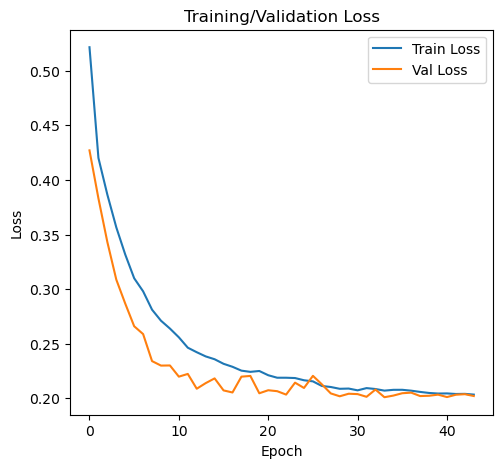


Train Set Evaluation:
Accuracy: 0.9996
Precision: 0.9994
Recall: 0.9998
F1-score: 0.9996
MCC: 0.9993
Cohen's Kappa: 0.9992

Validation Set Evaluation:


/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.9990
Precision: 0.9987
Recall: 0.9992
F1-score: 0.9990
MCC: 0.9980
Cohen's Kappa: 0.9980


/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


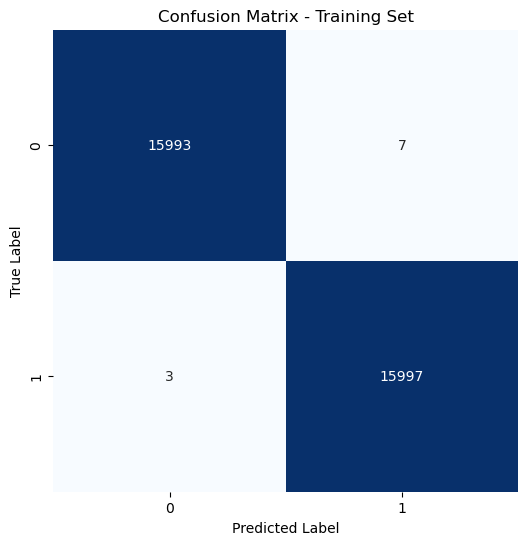

/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


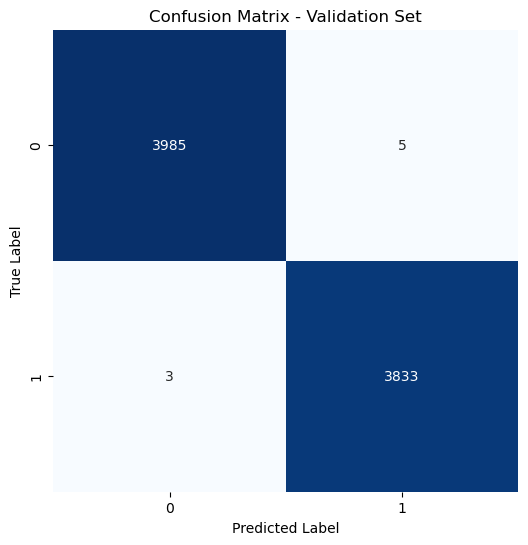

In [ ]:
if __name__ == "__main__":
    dataset_train = PeptideDataset("train_filtered.csv", augment=True)
    dataset_val = PeptideDataset("val_filtered.csv", augment=True)

    train_loader = DataLoader(dataset_train, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(dataset_val, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)

    model = MultimodalClassifier()

    # Use label smoothing and gradient clipping
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=100, patience=10, grad_clip=1.0, grad_accum_steps=2
    )

    plot_history(history)

    print("\nTrain Set Evaluation:")
    train_metrics = evaluate_model(model, train_loader)

    print("\nValidation Set Evaluation:")
    val_metrics = evaluate_model(model, val_loader)

    # Confusion matrix plotting
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    def plot_confusion_matrix(model, data_loader, title):
        all_preds, all_labels = [], []
        with torch.no_grad():
            for sequences, labels in data_loader:
                esm_feats = extract_esm_embeddings(sequences)
                onehot_seqs = sequence_to_onehot(sequences).float()
                outputs = model(esm_feats, onehot_seqs)
                preds = torch.argmax(outputs, dim=1).numpy()
                all_preds.extend(preds)
                all_labels.extend(labels)

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(title)
        plt.show()

    plot_confusion_matrix(model, train_loader, "Confusion Matrix - Training Set")
    plot_confusion_matrix(model, val_loader, "Confusion Matrix - Validation Set")

/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


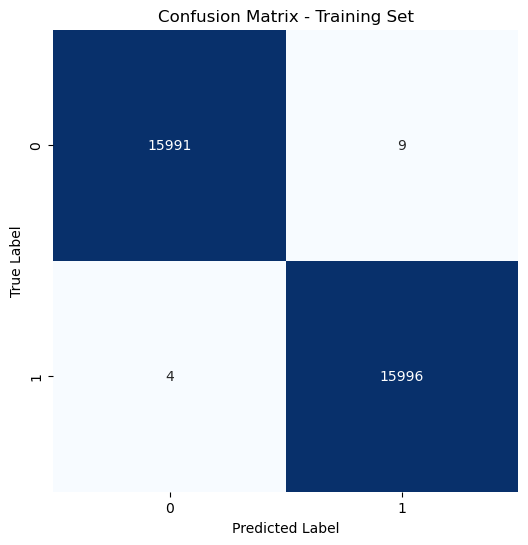

/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


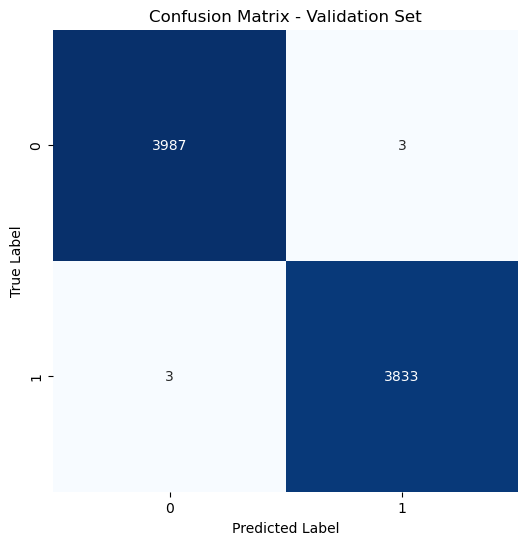

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, data_loader, title):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sequences, labels in data_loader:
            esm_feats = extract_esm_embeddings(sequences)
            onehot_seqs = sequence_to_onehot(sequences).float()
            outputs = model(esm_feats, onehot_seqs)
            preds = torch.argmax(outputs, dim=1).numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(model, train_loader, "Confusion Matrix - Training Set")
plot_confusion_matrix(model, val_loader, "Confusion Matrix - Validation Set")


In [ ]:
import pandas as df
df = pd.read_csv("train_filtered.csv")
counts = df['FRS'].value_counts()
print(counts)

FRS
0    16000
1    16000
Name: count, dtype: int64


In [ ]:
import pandas as df
df = pd.read_csv("val_filtered.csv")
counts = df['FRS'].value_counts()
print(counts)

FRS
0    3990
1    3836
Name: count, dtype: int64


In [ ]:
# Save the trained model
torch.save(model.state_dict(), '01_AO_db_testsplit_classifier.pth')

In [6]:
# To open the trained model, you would load the state dictionary back into a model instance
# First, instantiate a new model with the same architecture
model = MultimodalClassifier()

# Then, load the saved state dictionary
model.load_state_dict(torch.load('01_AO_db_testsplit_classifier.pth'))

# Set the model to evaluation mode
model.eval()

print("Model loaded successfully!")

# You can now use loaded_model for inference on new data.
# Example (assuming you have new_sequences):
new_sequences = ["ARGLAKL", "AAVVRR"]
new_esm_feats = extract_esm_embeddings(new_sequences)
new_onehot_seqs = sequence_to_onehot(new_sequences).float()
with torch.no_grad():
     predictions = model(new_esm_feats, new_onehot_seqs)
     predicted_classes = torch.argmax(predictions, dim=1)
     print("Predictions:", predicted_classes)

Model loaded successfully!
Predictions: tensor([1, 0])


In [ ]:
# To open the trained model, you would load the state dictionary back into a model instance
# First, instantiate a new model with the same architecture
model = MultimodalClassifier()

# Then, load the saved state dictionary
model.load_state_dict(torch.load('01_AO_db_testsplit_classifier.pth'))

# Set the model to evaluation mode
model.eval()

print("Model loaded successfully!")

# You can now use loaded_model for inference on new data.
# Example (assuming you have new_sequences):

import pandas as pd
# Load the original dataframe
df = pd.read_csv('01_AO_db_test.csv')
df

new_sequences = df["sequence"]
new_esm_feats = extract_esm_embeddings(new_sequences)
new_onehot_seqs = sequence_to_onehot(new_sequences).float()
with torch.no_grad():
     predictions = model(new_esm_feats, new_onehot_seqs)
     predicted_classes = torch.argmax(predictions, dim=1)
     print("Predictions:", predicted_classes)

Model loaded successfully!
Predictions: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0])


In [7]:
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for sequences, labels in DataLoader(dataset_train, batch_size=32):
        esm_feats = extract_esm_embeddings(sequences)
        onehot = sequence_to_onehot(sequences).float()

        tcn_out = model.tcn(onehot.permute(0,2,1))
        # Add global pooling to get a fixed-size representation from TCN output
        tcn_summary = torch.mean(tcn_out, dim=2) # Corrected line
        fused = model.fusion(esm_feats, tcn_summary) # Pass tcn_summary instead of tcn_out

        all_embeddings.append(fused.cpu().numpy())
        all_labels.extend(labels)

Z = np.vstack(all_embeddings)
labels = np.array(all_labels)

# Cosine similarity
sim_matrix = cosine_similarity(Z)

# Intra-class diversity
for cls in [0,1]:
    idx = np.where(labels == cls)[0]
    intra = sim_matrix[np.ix_(idx, idx)]
    diversity = 1 - np.mean(intra)
    print(f"Intra-class diversity (Class {cls}):", diversity)

# Inter-class similarity
idx0 = np.where(labels == 0)[0]
idx1 = np.where(labels == 1)[0]
inter = sim_matrix[np.ix_(idx0, idx1)]
print("Inter-class similarity:", np.mean(inter))

# Silhouette score
print("Silhouette Score:", silhouette_score(Z, labels))

# UMAP visualization
#reducer = umap.UMAP()
#Z_2d = reducer.fit_transform(Z)

#plt.figure(figsize=(6,5))
#sns.scatterplot(x=Z_2d[:,0], y=Z_2d[:,1], hue=labels)
#plt.title("Multimodal Embedding Space")
#plt.show()

Intra-class diversity (Class 0): 0.55929303
Intra-class diversity (Class 1): 0.5679507
Inter-class similarity: 0.33743495
Silhouette Score: 0.07956783


In [ ]:
def compute_diversity_metrics(Z, labels):
    """
    Computes:
    - Intra-class diversity
    - Inter-class similarity
    - Separation index
    - Silhouette score
    """
    sim_matrix = cosine_similarity(Z)
    labels = np.array(labels)

    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    intra0 = sim_matrix[np.ix_(idx0, idx0)]
    intra1 = sim_matrix[np.ix_(idx1, idx1)]
    inter = sim_matrix[np.ix_(idx0, idx1)]

    # Diversity = 1 - mean cosine similarity
    div0 = 1 - np.mean(intra0)
    div1 = 1 - np.mean(intra1)
    inter_sim = np.mean(inter)

    separation_index = (1 - inter_sim) / np.mean([div0, div1])
    silhouette = silhouette_score(Z, labels)

    metrics = {
        "Intra-class diversity (0)": div0,
        "Intra-class diversity (1)": div1,
        "Inter-class similarity": inter_sim,
        "Separation index": separation_index,
        "Silhouette score": silhouette
    }

    return metrics
metrics_dict = compute_diversity_metrics(Z, labels)
metrics_df = pd.DataFrame([metrics_dict])
metrics_df

,Intra-class diversity (0),Intra-class diversity (1),Inter-class similarity,Separation index,Silhouette score
0,0.573382,0.533451,0.302153,1.260979,0.112281


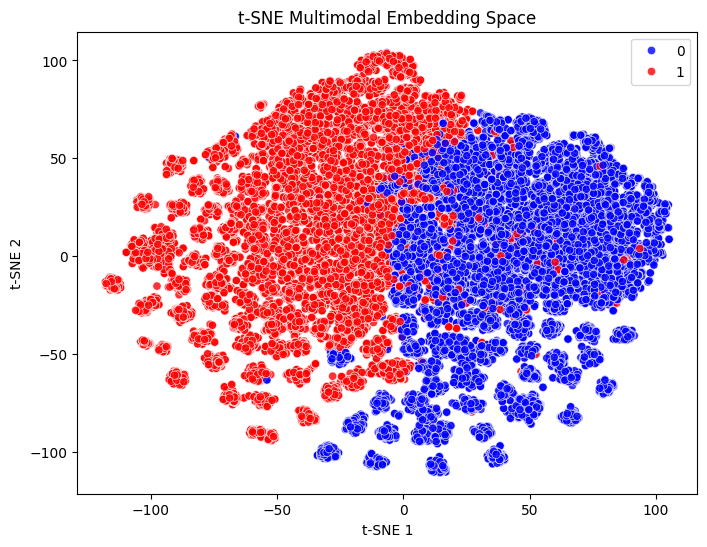

In [8]:
import seaborn as sns
from sklearn.manifold import TSNE
def plot_tsne(Z, labels, perplexity=30):
    """
    t-SNE projection of multimodal embeddings.
    """
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=42
    )

    Z_2d = tsne.fit_transform(Z)

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=Z_2d[:,0],
        y=Z_2d[:,1],
        hue=labels,
        palette=["blue", "red"],
        alpha=0.8
    )

    plt.title("t-SNE Multimodal Embedding Space")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.show()

    return Z_2d

Z_2d = plot_tsne(Z, labels, perplexity=30)

100%|███████████████████████████████████████| 1000/1000 [23:29<00:00,  1.41s/it]

Observed statistic (div1 - div0): -0.0399
Permutation p-value: 0.00000


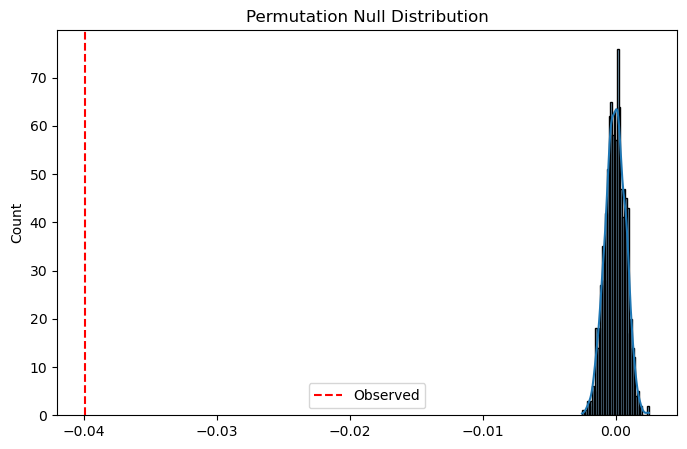

In [ ]:
def permutation_test_diversity(Z, labels, n_permutations=1000):
    """
    Permutation test for diversity difference between classes.
    """
    labels = np.array(labels)
    sim_matrix = cosine_similarity(Z)

    def compute_stat(lbls):
        idx0 = np.where(lbls == 0)[0]
        idx1 = np.where(lbls == 1)[0]

        intra0 = 1 - np.mean(sim_matrix[np.ix_(idx0, idx0)])
        intra1 = 1 - np.mean(sim_matrix[np.ix_(idx1, idx1)])

        return intra1 - intra0

    observed_stat = compute_stat(labels)
    perm_stats = []

    for _ in tqdm(range(n_permutations)):
        permuted_labels = np.random.permutation(labels)
        perm_stats.append(compute_stat(permuted_labels))

    perm_stats = np.array(perm_stats)

    p_value = np.mean(np.abs(perm_stats) >= np.abs(observed_stat))

    print(f"Observed statistic (div1 - div0): {observed_stat:.4f}")
    print(f"Permutation p-value: {p_value:.5f}")

    # Plot null distribution
    plt.figure(figsize=(8,5))
    sns.histplot(perm_stats, bins=40, kde=True)
    plt.axvline(observed_stat, color="red", linestyle="--", label="Observed")
    plt.title("Permutation Null Distribution")
    plt.legend()
    plt.show()

    return observed_stat, p_value

observed_stat, p_value = permutation_test_diversity(Z, labels, n_permutations=1000)

In [ ]:
def bootstrap_diversity_ci(Z, labels, n_bootstrap=1000):
    """
    Bootstrap confidence intervals for intra-class diversity.
    """
    labels = np.array(labels)
    sim_matrix = cosine_similarity(Z)

    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    boot_div0 = []
    boot_div1 = []

    for _ in tqdm(range(n_bootstrap)):
        sample0 = np.random.choice(idx0, size=len(idx0), replace=True)
        sample1 = np.random.choice(idx1, size=len(idx1), replace=True)

        div0 = 1 - np.mean(sim_matrix[np.ix_(sample0, sample0)])
        div1 = 1 - np.mean(sim_matrix[np.ix_(sample1, sample1)])

        boot_div0.append(div0)
        boot_div1.append(div1)

    ci0 = np.percentile(boot_div0, [2.5, 97.5])
    ci1 = np.percentile(boot_div1, [2.5, 97.5])

    print(f"Class 0 Diversity 95% CI: {ci0}")
    print(f"Class 1 Diversity 95% CI: {ci1}")

    return ci0, ci1

ci0, ci1 = bootstrap_diversity_ci(Z, labels, n_bootstrap=1000)

100%|███████████████████████████████████████| 1000/1000 [31:46<00:00,  1.91s/it]

Class 0 Diversity 95% CI: [0.57204865 0.57462253]
Class 1 Diversity 95% CI: [0.53176909 0.53500398]


In [9]:
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for sequences, labels in DataLoader(dataset_val, batch_size=32):
        esm_feats = extract_esm_embeddings(sequences)
        onehot = sequence_to_onehot(sequences).float()

        tcn_out = model.tcn(onehot.permute(0,2,1))
        # Add global pooling to get a fixed-size representation from TCN output
        tcn_summary = torch.mean(tcn_out, dim=2) # Corrected line
        fused = model.fusion(esm_feats, tcn_summary) # Pass tcn_summary instead of tcn_out

        all_embeddings.append(fused.cpu().numpy())
        all_labels.extend(labels)

Z = np.vstack(all_embeddings)
labels = np.array(all_labels)

# Cosine similarity
sim_matrix = cosine_similarity(Z)

# Intra-class diversity
for cls in [0,1]:
    idx = np.where(labels == cls)[0]
    intra = sim_matrix[np.ix_(idx, idx)]
    diversity = 1 - np.mean(intra)
    print(f"Intra-class diversity (Class {cls}):", diversity)

# Inter-class similarity
idx0 = np.where(labels == 0)[0]
idx1 = np.where(labels == 1)[0]
inter = sim_matrix[np.ix_(idx0, idx1)]
print("Inter-class similarity:", np.mean(inter))

# Silhouette score
print("Silhouette Score:", silhouette_score(Z, labels))

# UMAP visualization
#reducer = umap.UMAP()
#Z_2d = reducer.fit_transform(Z)

#plt.figure(figsize=(6,5))
#sns.scatterplot(x=Z_2d[:,0], y=Z_2d[:,1], hue=labels)
#plt.title("Multimodal Embedding Space")
#plt.show()

Intra-class diversity (Class 0): 0.5601181
Intra-class diversity (Class 1): 0.57079774
Inter-class similarity: 0.33987212
Silhouette Score: 0.07618768


In [ ]:
def compute_diversity_metrics(Z, labels):
    """
    Computes:
    - Intra-class diversity
    - Inter-class similarity
    - Separation index
    - Silhouette score
    """
    sim_matrix = cosine_similarity(Z)
    labels = np.array(labels)

    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    intra0 = sim_matrix[np.ix_(idx0, idx0)]
    intra1 = sim_matrix[np.ix_(idx1, idx1)]
    inter = sim_matrix[np.ix_(idx0, idx1)]

    # Diversity = 1 - mean cosine similarity
    div0 = 1 - np.mean(intra0)
    div1 = 1 - np.mean(intra1)
    inter_sim = np.mean(inter)

    separation_index = (1 - inter_sim) / np.mean([div0, div1])
    silhouette = silhouette_score(Z, labels)

    metrics = {
        "Intra-class diversity (0)": div0,
        "Intra-class diversity (1)": div1,
        "Inter-class similarity": inter_sim,
        "Separation index": separation_index,
        "Silhouette score": silhouette
    }

    return metrics
metrics_dict = compute_diversity_metrics(Z, labels)
metrics_df = pd.DataFrame([metrics_dict])
metrics_df

,Intra-class diversity (0),Intra-class diversity (1),Inter-class similarity,Separation index,Silhouette score
0,0.57408,0.539248,0.303284,1.25159,0.108491


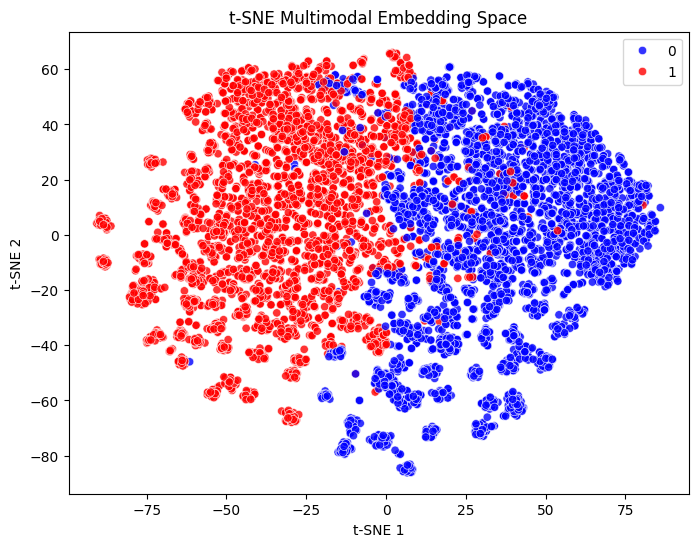

In [10]:
def plot_tsne(Z, labels, perplexity=30):
    """
    t-SNE projection of multimodal embeddings.
    """
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=42
    )

    Z_2d = tsne.fit_transform(Z)

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=Z_2d[:,0],
        y=Z_2d[:,1],
        hue=labels,
        palette=["blue", "red"],
        alpha=0.8
    )

    plt.title("t-SNE Multimodal Embedding Space")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.show()

    return Z_2d

Z_2d = plot_tsne(Z, labels, perplexity=30)

100%|███████████████████████████████████████| 1000/1000 [01:26<00:00, 11.57it/s]


Observed statistic (div1 - div0): -0.0348
Permutation p-value: 0.00000


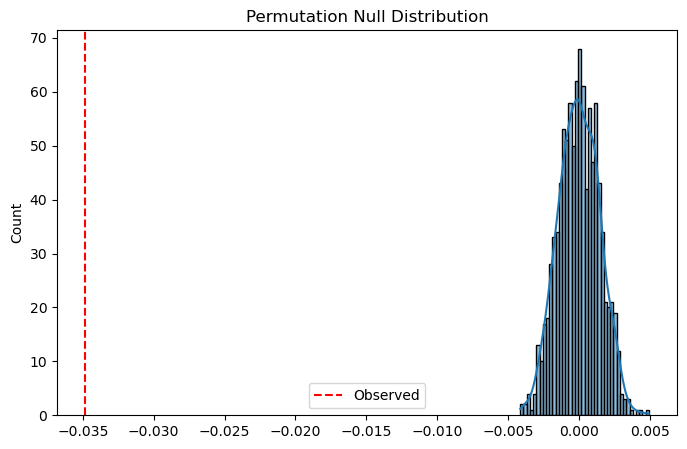

In [ ]:
def permutation_test_diversity(Z, labels, n_permutations=1000):
    """
    Permutation test for diversity difference between classes.
    """
    labels = np.array(labels)
    sim_matrix = cosine_similarity(Z)

    def compute_stat(lbls):
        idx0 = np.where(lbls == 0)[0]
        idx1 = np.where(lbls == 1)[0]

        intra0 = 1 - np.mean(sim_matrix[np.ix_(idx0, idx0)])
        intra1 = 1 - np.mean(sim_matrix[np.ix_(idx1, idx1)])

        return intra1 - intra0

    observed_stat = compute_stat(labels)
    perm_stats = []

    for _ in tqdm(range(n_permutations)):
        permuted_labels = np.random.permutation(labels)
        perm_stats.append(compute_stat(permuted_labels))

    perm_stats = np.array(perm_stats)

    p_value = np.mean(np.abs(perm_stats) >= np.abs(observed_stat))

    print(f"Observed statistic (div1 - div0): {observed_stat:.4f}")
    print(f"Permutation p-value: {p_value:.5f}")

    # Plot null distribution
    plt.figure(figsize=(8,5))
    sns.histplot(perm_stats, bins=40, kde=True)
    plt.axvline(observed_stat, color="red", linestyle="--", label="Observed")
    plt.title("Permutation Null Distribution")
    plt.legend()
    plt.show()

    return observed_stat, p_value

observed_stat, p_value = permutation_test_diversity(Z, labels, n_permutations=1000)

In [ ]:
def bootstrap_diversity_ci(Z, labels, n_bootstrap=1000):
    """
    Bootstrap confidence intervals for intra-class diversity.
    """
    labels = np.array(labels)
    sim_matrix = cosine_similarity(Z)

    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    boot_div0 = []
    boot_div1 = []

    for _ in tqdm(range(n_bootstrap)):
        sample0 = np.random.choice(idx0, size=len(idx0), replace=True)
        sample1 = np.random.choice(idx1, size=len(idx1), replace=True)

        div0 = 1 - np.mean(sim_matrix[np.ix_(sample0, sample0)])
        div1 = 1 - np.mean(sim_matrix[np.ix_(sample1, sample1)])

        boot_div0.append(div0)
        boot_div1.append(div1)

    ci0 = np.percentile(boot_div0, [2.5, 97.5])
    ci1 = np.percentile(boot_div1, [2.5, 97.5])

    print(f"Class 0 Diversity 95% CI: {ci0}")
    print(f"Class 1 Diversity 95% CI: {ci1}")

    return ci0, ci1

ci0, ci1 = bootstrap_diversity_ci(Z, labels, n_bootstrap=1000)

100%|███████████████████████████████████████| 1000/1000 [01:55<00:00,  8.64it/s]

Class 0 Diversity 95% CI: [0.57122026 0.57648972]
Class 1 Diversity 95% CI: [0.53602003 0.54229084]


In [ ]:
!pip install anchor-exp

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.8/32.8 MB 11.4 MB/s  0:00:02a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.9/839.9 kB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 11.6 MB/s  0:00:001.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 11.6 MB/s  0:00:00.8 MB/s eta 0:00:01:01
  Created wheel for anchor-exp: filename=anchor_exp-0.0.2.0-py3-none-any.whl size=433571 sha256=a5bf40b8876f1bf2108851e148003cdf16e2ec5c628f0adc019c4560e790428a
  Stored in directory: /home/molecular12/.cache/pip/wheels/b8/6a/a5/06eb4c26d0d6d86039c3aa7f708da8e0dcc783f1fd1ca1efa5
  Created w

In [ ]:
from anchor import anchor_text
import numpy as np
import torch
import pandas as pd

# === Load dataset ===
df = pd.read_csv("01_AO_db_test.csv")
df['sequence'] = df['sequence'].astype(str)
df['label'] = df['FRS']

# === Convert sequence to k-mers ===
def seq_to_kmers(seq, k=6):
    return ' '.join([seq[i:i + k] for i in range(len(seq) - k + 1)])

# === Convert k-mers back to sequence ===
def kmers_to_seq(kmer_str, k=6):
    kmers = kmer_str.split()
    if not kmers: return ''
    return kmers[0] + ''.join([k[-1] for k in kmers[1:]])

k = 6
df['kmers'] = df['sequence'].apply(lambda seq: seq_to_kmers(seq, k))
kmer_texts = df['kmers'].tolist()
raw_sequences = df['sequence'].tolist()
labels = df['label'].tolist()

# === Prediction using ESM + one-hot ===
def predict_fn_esm(sequences):
    model.eval()
    with torch.no_grad():
        valid_sequences = [s for s in sequences if isinstance(s, str) and len(s) > 0]
        if not valid_sequences:
            return np.array([[0.5, 0.5]] * len(sequences))

        esm_feats = extract_esm_embeddings(valid_sequences)
        onehot = sequence_to_onehot(valid_sequences).float()
        outputs = model(esm_feats, onehot)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()

        full_probs = np.zeros((len(sequences), 2))
        valid_idx = 0
        for i, seq in enumerate(sequences):
            if isinstance(seq, str) and len(seq) > 0:
                full_probs[i] = probs[valid_idx]
                valid_idx += 1
            else:
                full_probs[i] = np.array([0.5, 0.5])
        return full_probs

# === Wrapper for AnchorText (returns class predictions) ===
def predict_probs_kmers_anchor(kmer_seqs):
    recovered_seqs = [kmers_to_seq(text, k=k) for text in kmer_seqs]
    return predict_fn_esm(recovered_seqs)

def predict_class_kmers_anchor(kmer_seqs):
    probs = predict_probs_kmers_anchor(kmer_seqs)
    return np.argmax(probs, axis=1)

# === Dummy tokenizer for AnchorText ===
class DummyToken:
    def __init__(self, text, idx):
        self.text = text
        self.idx = idx

class DummyTokenizer:
    def __call__(self, text):
        tokens = text.split()
        return [DummyToken(token, i) for i, token in enumerate(tokens)]

# === Find top high-confidence toxic predictions ===
probs = predict_fn_esm(raw_sequences)
#high_conf_ids = np.where((np.array(labels) == 1) & (probs[:, 1] > 0.8))[0]
labels_arr = np.array(labels)
high_conf_ids = np.where((labels_arr == 1) & (probs[:, 1] > 0.8))[0]
selected_ids = high_conf_ids[:]

# === Create AnchorText explainer ===
class_names = ['non-FRS', 'FRS']
explainer = anchor_text.AnchorText(nlp=DummyTokenizer(), class_names=class_names)

# === Explain selected instances ===
explanation_data = []
for i, idx in enumerate(selected_ids):
    print(f"\n🧬 Explaining Sequence {i+1} (Index {idx})")
    print("Original Sequence:", raw_sequences[idx])

    explanation = explainer.explain_instance(
        kmer_texts[idx],
        classifier_fn=predict_class_kmers_anchor,
        threshold=0.95
    )

    print("\n🔍 Anchor Explanation:")
    print('Anchor (if these k-mers present → FRS):', ' AND '.join(explanation.names()))
    print('Precision:', explanation.precision())
    print('Coverage:', explanation.coverage())
    #explanation.show_in_notebook()
    # Collect the data
    anchor_kmers = ' AND '.join(explanation.names())
    precision = explanation.precision()
    coverage = explanation.coverage()


    #if explanation.precision() > 0.95 and explanation.coverage() > 0.95:
    if precision > 0.95 and coverage > 0.95:

       explanation_data.append({
        'Original Sequence': raw_sequences[idx],
        'Anchor (k-mers)': explanation.names(),
        'Precision': precision,
        'Coverage': coverage
       })

# Create DataFrame
explanation_df = pd.DataFrame(explanation_data)
explanation_df
# Display the DataFrame
#print("\nAnchor Explanations for High-Confidence FRS Sequences:")
#print(explanation_df.to_string())


🧬 Explaining Sequence 1 (Index 0)
Original Sequence: VQYPVEHPNKFLKFGMTPSKGVLFY

🔍 Anchor Explanation:
Anchor (if these k-mers present → FRS): VQYPVE AND TPSKGV AND KFLKFG
Precision: 0.9752066115702479
Coverage: 1.0

🧬 Explaining Sequence 2 (Index 1)
Original Sequence: AKAWGIPPHVIPQIVPVRIRPLCGNV

🔍 Anchor Explanation:
Anchor (if these k-mers present → FRS): AKAWGI AND PQIVPV
Precision: 0.9609756097560975
Coverage: 0.0

🧬 Explaining Sequence 3 (Index 2)
Original Sequence: GFWDSVKEGLKNAAVTILNKIKCKISECPPA

🔍 Anchor Explanation:
Anchor (if these k-mers present → FRS): GFWDSV AND DSVKEG AND LKNAAV AND KNAAVT AND IKCKIS AND KISECP AND CKISEC AND LNKIKC
Precision: 0.994413407821229
Coverage: 0.0

🧬 Explaining Sequence 4 (Index 3)
Original Sequence: FIPGLRRLFATVVPTVVCAINKLPPG

🔍 Anchor Explanation:
Anchor (if these k-mers present → FRS): RLFATV AND LFATVV AND VVPTVV AND FIPGLR
Precision: 0.9753694581280788
Coverage: 0.0

🧬 Explaining Sequence 5 (Index 4)
Original Sequence: SIITMTKEAKLPQLWKQIAC

,Original Sequence,Anchor (k-mers),Precision,Coverage
0,VQYPVEHPNKFLKFGMTPSKGVLFY,"[VQYPVE, TPSKGV, KFLKFG]",0.975207,1.0


In [ ]:
explanation_df.to_csv('explanation_anchor.csv')

In [ ]:
!pip install lime

In [ ]:
from lime.lime_text import LimeTextExplainer
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === Load dataset ===
df = pd.read_csv("01_AO_db_test.csv")
df['sequence'] = df['sequence'].astype(str)
df['label'] = df['FRS']

# Drop sequences with length smaller than 6 and create a new dataframe
#df = df[df['sequence'].str.len() >= 8].copy()

# === Tokenization into k-mers ===
def seq_to_kmers(seq, k=6):
    return ' '.join([seq[i:i + k] for i in range(len(seq) - k + 1)])

k = 6
df['kmers'] = df['sequence'].apply(lambda seq: seq_to_kmers(seq, k))

# === Helper to reconstruct full sequence from k-mers ===
def kmers_to_seq(kmer_str, k=6):
    kmers = kmer_str.split()
    if not kmers:
        return ''
    return kmers[0] + ''.join([k[-1] for k in kmers[1:]])

# === Prediction wrapper for LIME (accepts k-mer strings) ===
class_names = ['non-FRS', 'FRS']

def lime_predict_kmers(kmer_texts):
    # Convert k-mer text back to raw sequences
    sequences = [kmers_to_seq(text, k) for text in kmer_texts]

    model.eval()
    with torch.no_grad():
        # Filter out invalid inputs
        valid_sequences = [seq for seq in sequences if isinstance(seq, str) and len(seq) > 0]
        if not valid_sequences:
            return np.array([[0.5, 0.5]] * len(sequences))

        # ESM and one-hot encodings
        esm_feats = extract_esm_embeddings(valid_sequences)  # tensor [B, D]
        onehot_seqs = sequence_to_onehot(valid_sequences).float()  # tensor [B, L, 4]
        outputs = model(esm_feats, onehot_seqs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()

        # Reassign to full array
        full_probs = np.zeros((len(sequences), len(class_names)))
        valid_idx = 0
        for i, seq in enumerate(sequences):
            if isinstance(seq, str) and len(seq) > 0:
                full_probs[i] = probs[valid_idx]
                valid_idx += 1
            else:
                full_probs[i] = np.array([0.5, 0.5])
        return full_probs

# === LIME explainer with whitespace as k-mer separator ===
explainer = LimeTextExplainer(class_names=class_names, split_expression='\\s+')

# === Select top-N high-confidence toxic sequences ===
raw_sequences = df['sequence'].tolist()
labels = df['label'].tolist()
kmer_texts = df['kmers'].tolist()

probs = lime_predict_kmers(kmer_texts)
high_conf_ids = np.where((np.array(labels) == 1) & (probs[:, 1] > 0.8))[0]
selected_ids = high_conf_ids[:]

# === Run LIME explanation ===
for i, idx in enumerate(selected_ids):
    kmer_input = kmer_texts[idx]
    original_seq = df.iloc[idx]['sequence']

    explanation = explainer.explain_instance(kmer_input, lime_predict_kmers, num_features=10, labels=[1], num_samples=1000)

    print(f"\n🧬 Sequence {i+1}: {original_seq}")
    print("Top influential k-mers (toward Antioxidant):")
    for token, weight in explanation.as_list(label=1):
        print(f"  {token}: {weight:.4f}")

    # Highlight influential regions in the original sequence
    highlighted = original_seq
    sorted_kmers = sorted(explanation.as_list(label=1), key=lambda x: abs(x[1]), reverse=True)
    for kmer, _ in sorted_kmers:
        highlighted = highlighted.replace(kmer, f"<{kmer}>")
    print("Highlighted:", highlighted)

    try:
        explanation.show_in_notebook()
        fig = explanation.as_pyplot_figure(label=1)
        plt.title(f"LIME Explanation for Sequence {i+1}")
        plt.show()
    except Exception as e:
        print(f"Could not generate plot for sequence {i+1}: {e}")


🧬 Sequence 1: VQYPVEHPNKFLKFGMTPSKGVLFY
Top influential k-mers (toward Allergen):
  QYPVEH: 0.0557
  YPVEHP: 0.0424
  KGVLFY: 0.0291
  PSKGVL: 0.0290
  TPSKGV: 0.0269
  HPNKFL: 0.0252
  EHPNKF: 0.0248
  SKGVLF: 0.0242
  PVEHPN: -0.0199
  LKFGMT: 0.0178
Highlighted: V<QYPVEH>PNKF<LKFGMT>PS<KGVLFY>
Could not generate plot for sequence 1: cannot import name 'display' from 'IPython.core.display' (/home/molecular12/anaconda3/lib/python3.13/site-packages/IPython/core/display.py)

🧬 Sequence 2: AKAWGIPPHVIPQIVPVRIRPLCGNV
Top influential k-mers (toward Allergen):
  WGIPPH: 0.0824
  RIRPLC: 0.0719
  PVRIRP: 0.0647
  KAWGIP: 0.0630
  AKAWGI: 0.0494
  AWGIPP: 0.0324
  IRPLCG: 0.0269
  IPPHVI: 0.0230
  VPVRIR: 0.0176
  IVPVRI: -0.0167
Highlighted: AKA<WGIPPH>VIPQIVPV<RIRPLC>GNV
Could not generate plot for sequence 2: cannot import name 'display' from 'IPython.core.display' (/home/molecular12/anaconda3/lib/python3.13/site-packages/IPython/core/display.py)

🧬 Sequence 3: GFWDSVKEGLKNAAVTILNKIKCKISE

In [ ]:
import pandas as pd
import numpy as np
from lime.lime_text import LimeTextExplainer

# === Load dataset ===
df = pd.read_csv("01_AO_db_test.csv")
df['sequence'] = df['sequence'].astype(str).fillna('')
df['label'] = df['FRS'].astype(int)

# === k-mer functions ===
def seq_to_kmers(seq, k=6):
    return ' '.join([seq[i:i + k] for i in range(len(seq) - k + 1)])

k = 6
df['kmers'] = df['sequence'].apply(lambda seq: seq_to_kmers(seq, k))

# === LIME expects raw text input ===
kmer_texts = df['kmers'].tolist()
raw_sequences = df['sequence'].tolist()

# === Wrapper for LIME ===
def predict_probs_lime(texts):
    # Convert k-mers back to sequences
    sequences = [kmers_to_seq(t, k=k) for t in texts]
    return predict_fn_esm(sequences)

# === Prediction using ESM + one-hot ===
def predict_fn_esm(sequences):
    model.eval()
    with torch.no_grad():
        valid_sequences = [s for s in sequences if isinstance(s, str) and len(s) > 0]
        if not valid_sequences:
            return np.array([[0.5, 0.5]] * len(sequences))

        esm_feats = extract_esm_embeddings(valid_sequences)
        onehot = sequence_to_onehot(valid_sequences).float()
        outputs = model(esm_feats, onehot)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()

        full_probs = np.zeros((len(sequences), 2))
        valid_idx = 0
        for i, seq in enumerate(sequences):
            if isinstance(seq, str) and len(seq) > 0:
                full_probs[i] = probs[valid_idx]
                valid_idx += 1
            else:
                full_probs[i] = np.array([0.5, 0.5])
        return full_probs


# === Initialize LIME ===
explainer = LimeTextExplainer(class_names=['non-FRS', 'FRS'])

# === Storage ===
lime_data = []

# === Explain instances ===
for i in range(len(df)):
    print(f"Explaining {i+1}/{len(df)}")

    exp = explainer.explain_instance(
        kmer_texts[i],
        classifier_fn=predict_probs_lime,
        num_features=10
    )

    # === Extract top k-mers ===
    top_features = exp.as_list()
    top_kmers = [feat for feat, weight in top_features if weight > 0]

    # === Highlight k-mers in original sequence ===
    seq = raw_sequences[i]
    highlighted_seq = seq

    for kmer in top_kmers:
        highlighted_seq = highlighted_seq.replace(kmer, f"[{kmer}]")

    # === Store ===
    lime_data.append({
        'Original Sequence': seq,
        'Top Influential k-mers': top_kmers,
        'Highlighted Sequence': highlighted_seq
    })

# === Create DataFrame ===
lime_df = pd.DataFrame(lime_data)
lime_df

Explaining 1/20
Explaining 2/20
Explaining 3/20
Explaining 4/20
Explaining 5/20
Explaining 6/20
Explaining 7/20
Explaining 8/20
Explaining 9/20
Explaining 10/20
Explaining 11/20
Explaining 12/20
Explaining 13/20
Explaining 14/20
Explaining 15/20
Explaining 16/20
Explaining 17/20
Explaining 18/20
Explaining 19/20
Explaining 20/20


,Original Sequence,Top Influential k-mers,Highlighted Sequence
0,VQYPVEHPNKFLKFGMTPSKGVLFY,"[QYPVEH, KGVLFY, YPVEHP, TPSKGV, MTPSKG, EHPNK...",V[QYPVEH]PNK[FLKFGM]TPS[KGVLFY]
1,AKAWGIPPHVIPQIVPVRIRPLCGNV,"[WGIPPH, KAWGIP, RIRPLC, AKAWGI, PVRIRP, AWGIP...",AKA[WGIPPH]V[IPQIVP]V[RIRPLC]GNV
2,GFWDSVKEGLKNAAVTILNKIKCKISECPPA,"[CKISEC, KISECP, SVKEGL, ISECPP, WDSVKE, KNAAV...",GFWD[SVKEGL][KNAAVT]ILNKIK[CKISEC]PPA
3,FIPGLRRLFATVVPTVVCAINKLPPG,"[VVCAIN, VPTVVC, VCAINK, PGLRRL, FIPGLR, GLRRL...",FI[PGLRRL]FATVVPT[VVCAIN]KLPPG
4,SIITMTKEAKLPQLWKQIACRLYNTC,"[IACRLY, WKQIAC, RLYNTC, KLPQLW, SIITMT, TKEAK...",[SIITMT]KEA[KLPQLW]KQ[IACRLY]NTC
5,FRSGILKLASKIPSVLCAVLKNC,"[FRSGIL, ASKIPS, ILKLAS, RSGILK, LASKIP, IPSVL...",[FRSGIL]KL[ASKIPS]VLC[AVLKNC]
6,DDPDKGMLKWKNDFFQEF,"[NDFFQE, KGMLKW, LKWKND, DFFQEF, DPDKGM, DDPDK...",DDPD[KGMLKW]K[NDFFQE]F
7,GLLDSVKEGLKKVAGQLLDTLKCKISGCTPA,"[GQLLDT, CKISGC, LLDSVK, KKVAGQ, ISGCTP, GLKKV...",G[LLDSVK]E[GLKKVA][GQLLDT]LK[CKISGC]TPA
8,GFFDRIKALTKNVTLELLNTITCKLPVTPP,"[KNVTLE, LNTITC, LTKNVT, GFFDRI, ALTKNV, LELLN...",[GFFDRI]KALT[KNVTLE]L[LNTITC]KLPVTPP
9,SFGAKNAVKNGLQKLRNQCQANNYQGPFCDIFKKNP,"[KLRNQC, CQANNY, GLQKLR, PFCDIF, NYQGPF, YQGPF...",SF[GAKNAV]KNGLQ[KLRNQC]QANNYQG[PFCDIF]KKNP


In [ ]:
lime_df.to_csv('explanation_lime.csv')

In [ ]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 11.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]━━━━━━ 1/2 [shap]



🧬 Sequence 1: VQYPVEHPNKFLKFGMTPSKGVLFY
Top 5 influential k-mers:
  PNKFLK: 0.0011
  VQYPVE: -0.0011
  HPNKFL: 0.0009
  PVEHPN: 0.0006
  KGVLFY: -0.0005
Highlighted: [VQYPVE]H[PNKFLK]FGMTPS[KGVLFY]


/home/molecular12/anaconda3/lib/python3.13/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/home/molecular12/anaconda3/lib/python3.13/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/home/molecular12/anaconda3/lib/python3.13/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: Chomp1d
  warnings.warn(f"unrecognized nn.Module: {module_type}")


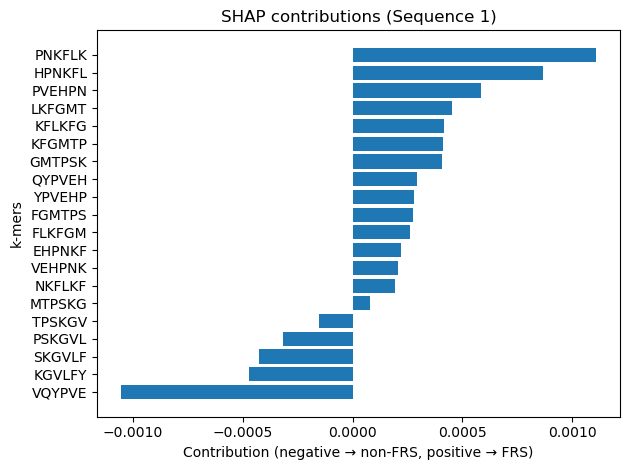


🧬 Sequence 2: AKAWGIPPHVIPQIVPVRIRPLCGNV
Top 5 influential k-mers:
  AKAWGI: -0.0009
  PHVIPQ: 0.0008
  KAWGIP: -0.0006
  PPHVIP: 0.0005
  IVPVRI: -0.0004
Highlighted: [AKAWGI]P[PHVIPQ][IVPVRI]RPLCGNV


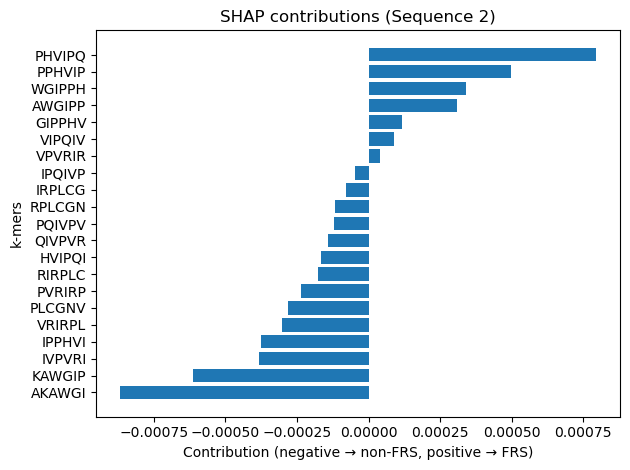


🧬 Sequence 3: GFWDSVKEGLKNAAVTILNKIKCKISECPPA
Top 5 influential k-mers:
  EGLKNA: 0.0008
  GFWDSV: -0.0006
  LKNAAV: 0.0003
  GLKNAA: 0.0003
  KEGLKN: 0.0002
Highlighted: [GFWDSV]K[EGLKNA]AVTILNKIKCKISECPPA


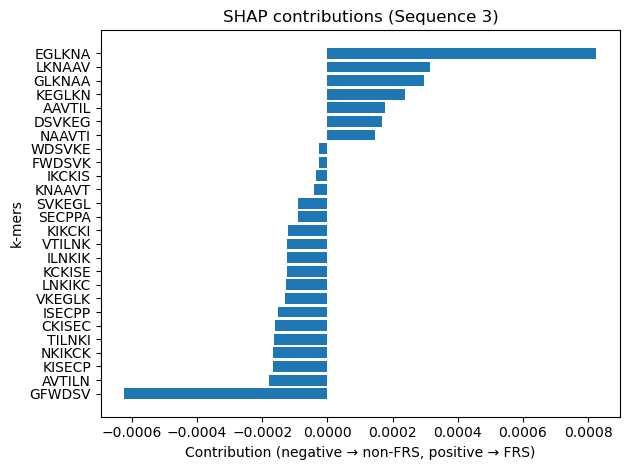


🧬 Sequence 4: FIPGLRRLFATVVPTVVCAINKLPPG
Top 5 influential k-mers:
  GLRRLF: 0.0007
  VVCAIN: -0.0005
  PGLRRL: 0.0005
  LFATVV: 0.0004
  IPGLRR: 0.0003
Highlighted: FIP[GLRRLF]ATVVPT[VVCAIN]KLPPG


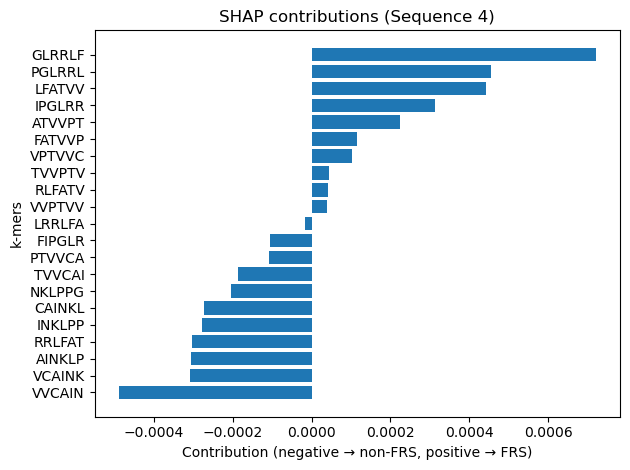


🧬 Sequence 5: SIITMTKEAKLPQLWKQIACRLYNTC
Top 5 influential k-mers:
  EAKLPQ: 0.0010
  TKEAKL: 0.0007
  TMTKEA: 0.0005
  MTKEAK: 0.0004
  KEAKLP: 0.0004
Highlighted: SIITMTK[EAKLPQ]LWKQIACRLYNTC


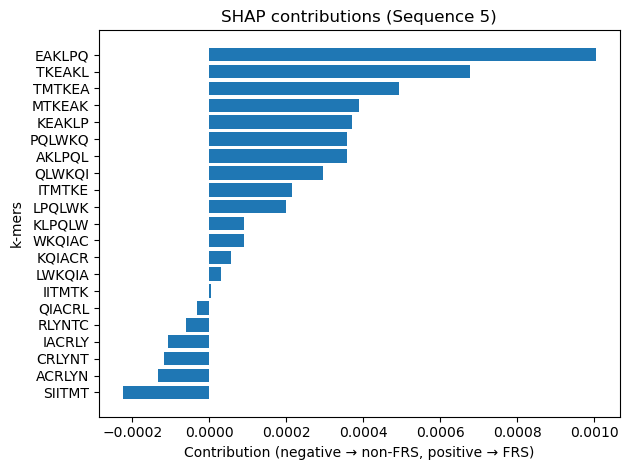


🧬 Sequence 6: FRSGILKLASKIPSVLCAVLKNC
Top 5 influential k-mers:
  LASKIP: 0.0005
  ILKLAS: 0.0005
  KIPSVL: -0.0004
  ASKIPS: 0.0004
  SVLCAV: -0.0004
Highlighted: FRSGILK[LASKIP][SVLCAV]LKNC


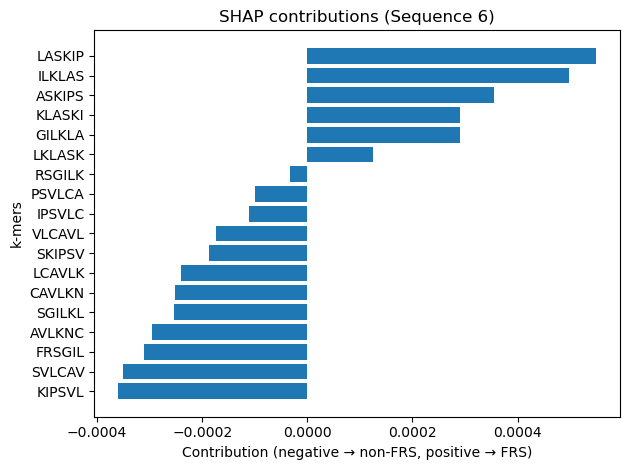


🧬 Sequence 7: DDPDKGMLKWKNDFFQEF
Top 5 influential k-mers:
  DPDKGM: 0.0007
  DKGMLK: 0.0006
  LKWKND: 0.0006
  KNDFFQ: -0.0004
  DFFQEF: -0.0004
Highlighted: D[DPDKGM][LKWKND]FFQEF


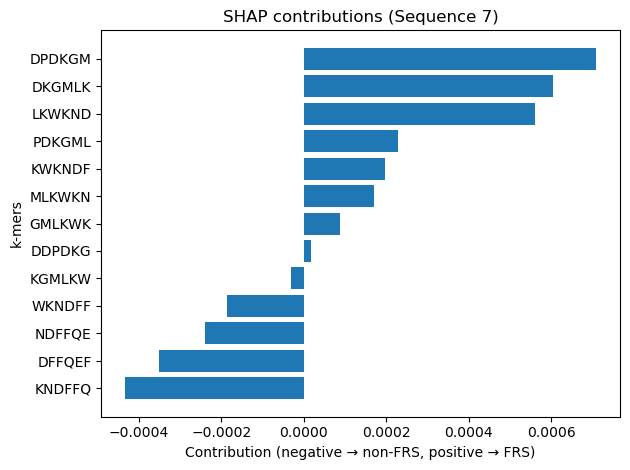


🧬 Sequence 8: GLLDSVKEGLKKVAGQLLDTLKCKISGCTPA
Top 5 influential k-mers:
  GLLDSV: -0.0007
  EGLKKV: 0.0006
  SVKEGL: -0.0004
  LDSVKE: -0.0003
  KEGLKK: 0.0003
Highlighted: [GLLDSV]K[EGLKKV]AGQLLDTLKCKISGCTPA


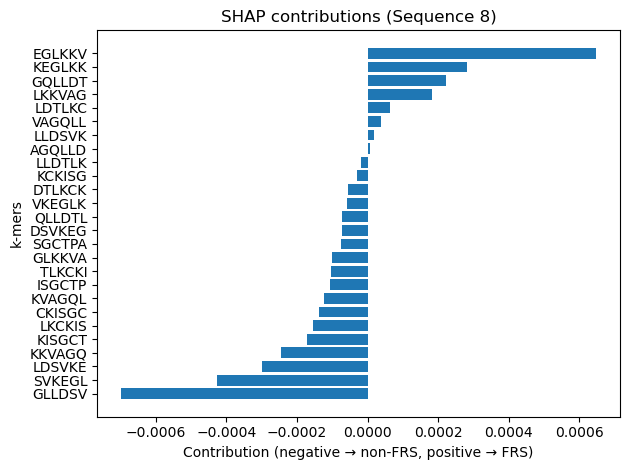


🧬 Sequence 9: GFFDRIKALTKNVTLELLNTITCKLPVTPP
Top 5 influential k-mers:
  DRIKAL: 0.0014
  FDRIKA: 0.0006
  KNVTLE: -0.0005
  TKNVTL: -0.0004
  IKALTK: -0.0003
Highlighted: GFF[DRIKAL]T[KNVTLE]LLNTITCKLPVTPP


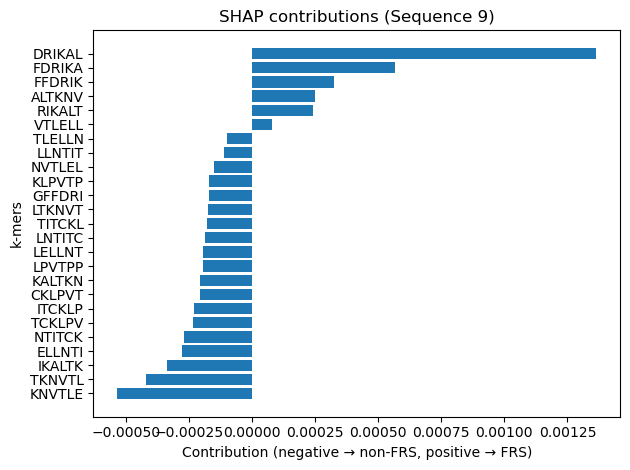


🧬 Sequence 10: SFGAKNAVKNGLQKLRNQCQANNYQGPFCDIFKKNP
Top 5 influential k-mers:
  GAKNAV: 0.0007
  FGAKNA: 0.0006
  VKNGLQ: 0.0006
  KNAVKN: -0.0006
  AVKNGL: 0.0004
Highlighted: SF[GAKNAV]KNGLQKLRNQCQANNYQGPFCDIFKKNP


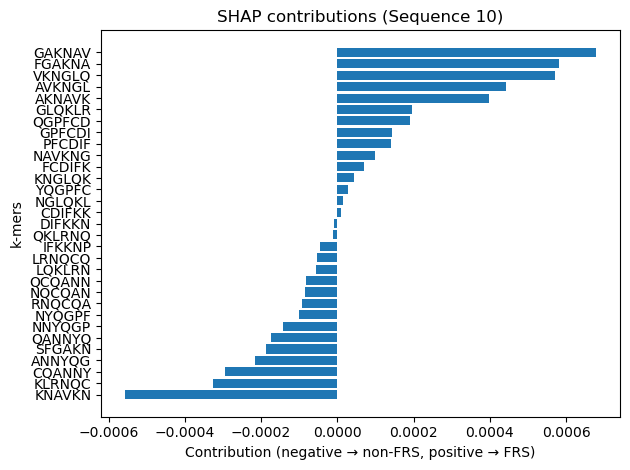


✅ SHAP DataFrame:


,Original Sequence,Top 5 k-mers,Highlighted Sequence
0,VQYPVEHPNKFLKFGMTPSKGVLFY,"[PNKFLK, VQYPVE, HPNKFL, PVEHPN, KGVLFY]",[VQYPVE]H[PNKFLK]FGMTPS[KGVLFY]
1,AKAWGIPPHVIPQIVPVRIRPLCGNV,"[AKAWGI, PHVIPQ, KAWGIP, PPHVIP, IVPVRI]",[AKAWGI]P[PHVIPQ][IVPVRI]RPLCGNV
2,GFWDSVKEGLKNAAVTILNKIKCKISECPPA,"[EGLKNA, GFWDSV, LKNAAV, GLKNAA, KEGLKN]",[GFWDSV]K[EGLKNA]AVTILNKIKCKISECPPA
3,FIPGLRRLFATVVPTVVCAINKLPPG,"[GLRRLF, VVCAIN, PGLRRL, LFATVV, IPGLRR]",FIP[GLRRLF]ATVVPT[VVCAIN]KLPPG
4,SIITMTKEAKLPQLWKQIACRLYNTC,"[EAKLPQ, TKEAKL, TMTKEA, MTKEAK, KEAKLP]",SIITMTK[EAKLPQ]LWKQIACRLYNTC
5,FRSGILKLASKIPSVLCAVLKNC,"[LASKIP, ILKLAS, KIPSVL, ASKIPS, SVLCAV]",FRSGILK[LASKIP][SVLCAV]LKNC
6,DDPDKGMLKWKNDFFQEF,"[DPDKGM, DKGMLK, LKWKND, KNDFFQ, DFFQEF]",D[DPDKGM][LKWKND]FFQEF
7,GLLDSVKEGLKKVAGQLLDTLKCKISGCTPA,"[GLLDSV, EGLKKV, SVKEGL, LDSVKE, KEGLKK]",[GLLDSV]K[EGLKKV]AGQLLDTLKCKISGCTPA
8,GFFDRIKALTKNVTLELLNTITCKLPVTPP,"[DRIKAL, FDRIKA, KNVTLE, TKNVTL, IKALTK]",GFF[DRIKAL]T[KNVTLE]LLNTITCKLPVTPP
9,SFGAKNAVKNGLQKLRNQCQANNYQGPFCDIFKKNP,"[GAKNAV, FGAKNA, VKNGLQ, KNAVKN, AVKNGL]",SF[GAKNAV]KNGLQKLRNQCQANNYQGPFCDIFKKNP


In [ ]:
import shap
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === Load dataset ===
df = pd.read_csv("01_AO_db_test.csv")
df['sequence'] = df['sequence'].astype(str).fillna('')
df['label'] = df['FRS'].astype(int)

# Drop sequences with length smaller than 6 and create a new dataframe
#df = df[df['sequence'].str.len() >= 8].copy()

# === Tokenization into k-mers ===
def seq_to_kmers(seq, k=6):
    return ' '.join([seq[i:i + k] for i in range(len(seq) - k + 1)])

k = 6
df['kmers'] = df['sequence'].apply(lambda seq: seq_to_kmers(seq, k))

# === Helper to reconstruct full sequence from k-mers ===
def kmers_to_seq(kmer_str, k=6):
    kmers = kmer_str.split()
    if not kmers:
        return ''
    return kmers[0] + ''.join([k[-1] for k in kmers[1:]])

# === Prediction wrapper for SHAP ===
class_names = ['non-FRS', 'FRS']

def shap_predict_sequences(sequences):
    model.eval()
    with torch.no_grad():
        esm_feats = extract_esm_embeddings(sequences)  # tensor [B, D]
        onehot_seqs = sequence_to_onehot(sequences).float()  # tensor [B, L, 4]
        outputs = model(esm_feats, onehot_seqs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
    return probs

# === Select top-N high-confidence toxic sequences ===
raw_sequences = df['sequence'].tolist()
labels = df['label'].tolist()

probs = shap_predict_sequences(raw_sequences)
high_conf_ids = np.where((np.array(labels) == 1) & (probs[:, 1] > 0.8))[0]
selected_ids = high_conf_ids[:]

# === Build SHAP DeepExplainer ===
background_sequences = raw_sequences[:50]  # background sample
background_esm = extract_esm_embeddings(background_sequences)
background_onehot = sequence_to_onehot(background_sequences).float()

# Wrap model forward pass for SHAP
class WrapperModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, esm_feats, onehot_seqs):
        return self.model(esm_feats, onehot_seqs)

wrapped_model = WrapperModel(model)
explainer = shap.DeepExplainer(wrapped_model, [background_esm, background_onehot])

# === Storage for SHAP results ===
shap_results = []

for i, idx in enumerate(selected_ids):
    original_seq = raw_sequences[idx]
    kmer_tokens = seq_to_kmers(original_seq, k).split()

    esm_feats = extract_esm_embeddings([original_seq])
    onehot_seq = sequence_to_onehot([original_seq]).float()

    shap_values = explainer.shap_values([esm_feats, onehot_seq], check_additivity=False)

    # === Use signed contribution ===
    onehot_shap = shap_values[1][0]  # [L, 4]
    token_scores = onehot_shap.sum(axis=1)  # ✅ preserves sign

    # === Map scores to k-mers ===
    kmer_scores = []
    for j in range(len(kmer_tokens)):
        start = j
        end = j + k
        kmer_score = np.mean(token_scores[start:end])
        kmer_scores.append(kmer_score)

    kmer_scores = np.array(kmer_scores)

    # === Top 5 influential k-mers (by absolute importance) ===
    top_indices = np.argsort(-np.abs(kmer_scores))[:5]
    top_kmers = [kmer_tokens[j] for j in top_indices]
    top_scores = [kmer_scores[j] for j in top_indices]

    print(f"\n🧬 Sequence {i+1}: {original_seq}")
    print("Top 5 influential k-mers:")
    for km, sc in zip(top_kmers, top_scores):
        print(f"  {km}: {sc:.4f}")

    # === Highlight sequence ===
    highlighted = original_seq
    for km in top_kmers:
        highlighted = highlighted.replace(km, f"[{km}]")

    print("Highlighted:", highlighted)

    # === Save to DataFrame ===
    shap_results.append({
        'Original Sequence': original_seq,
        'Top 5 k-mers': top_kmers,
        #'Top 5 scores': top_scores,
        'Highlighted Sequence': highlighted
    })

    # === SHAP BAR PLOT (positive vs negative) ===
    sorted_idx = np.argsort(kmer_scores)

    plt.figure()
    plt.barh(
        np.array(kmer_tokens)[sorted_idx],
        kmer_scores[sorted_idx]
    )
    plt.title(f"SHAP contributions (Sequence {i+1})")
    plt.xlabel("Contribution (negative → non-FRS, positive → FRS)")
    plt.ylabel("k-mers")
    plt.tight_layout()
    plt.show()

# === Create DataFrame ===
shap_df = pd.DataFrame(shap_results)

# === Display ===
print("\n✅ SHAP DataFrame:")
shap_df

In [ ]:
shap_df.to_csv('explanation_shap.csv')

In [ ]:
!pip install logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 6.3 MB/s  0:00:026.4 MB/s eta 0:00:01:01


/home/molecular12/anaconda3/lib/python3.13/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LayerNorm
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/home/molecular12/anaconda3/lib/python3.13/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")
/home/molecular12/anaconda3/lib/python3.13/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: Chomp1d
  warnings.warn(f"unrecognized nn.Module: {module_type}")



🔥 Top Enriched Toxic Motifs:
       kmer  mean_shap  freq    zscore
128  DPDKGM   0.007819     1  7.396354
99   PQLWKQ   0.001555     1  1.723427
64   KISECP   0.001123     1  1.331788
218  IFKKNP   0.000856     1  1.090633
217  DIFKKN   0.000852     1  1.086951
216  CDIFKK   0.000851     1  1.085817
193  NAVKNG   0.000598     1  0.856964
81   TVVCAI   0.000074     1  0.382311
80   PTVVCA   0.000074     1  0.382311
83   VCAINK   0.000074     1  0.382311
82   VVCAIN   0.000074     1  0.382311
79   VPTVVC   0.000074     1  0.382311
121  PSVLCA   0.000066     1  0.374343
122  SVLCAV   0.000066     1  0.374343
124  LCAVLK   0.000066     1  0.374343
125  CAVLKN   0.000066     1  0.374343
123  VLCAVL   0.000066     1  0.374343
101  LWKQIA   0.000058     1  0.367256
100  QLWKQI   0.000058     1  0.367256
102  WKQIAC   0.000058     1  0.367256

🧬 Consensus Toxic Motifs:
['DPDKGM', 'PQLWKQ', 'KISECP', 'IFKKNP', 'DIFKKN', 'CDIFKK', 'NAVKNG', 'TVVCAI', 'PTVVCA', 'VCAINK', 'VVCAIN', 'VPTVVC', 'PS

<Figure size 1200x400 with 0 Axes>

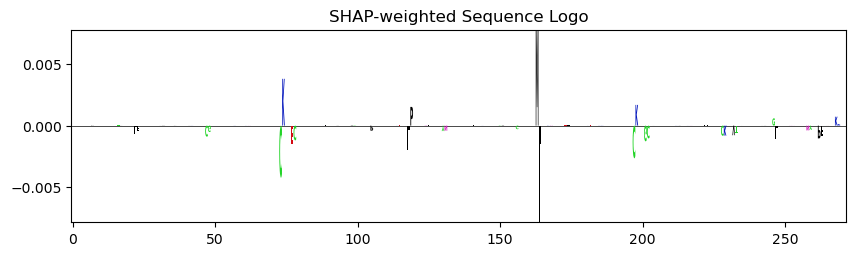

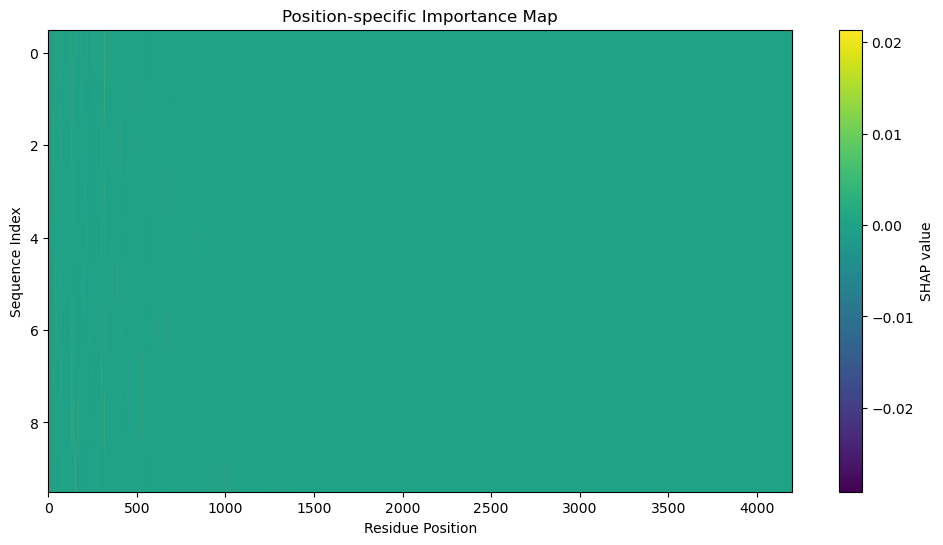

In [ ]:
import numpy as np
import pandas as pd
import torch
import shap
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import zscore
import logomaker

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("01_AO_db_test.csv")
df['sequence'] = df['sequence'].astype(str).fillna('')
df['label'] = df['FRS'].astype(int)

# =========================
# PARAMETERS
# =========================
k = 6

# =========================
# K-MER FUNCTION
# =========================
def seq_to_kmers(seq, k=6):
    return [seq[i:i+k] for i in range(len(seq)-k+1)]

# =========================
# MODEL WRAPPER
# =========================
def shap_predict(sequences):
    model.eval()
    with torch.no_grad():
        esm_feats = extract_esm_embeddings(sequences)
        onehot = sequence_to_onehot(sequences).float()
        outputs = model(esm_feats, onehot)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
    return probs.astype(np.float64)

# =========================
# BACKGROUND FOR SHAP
# =========================
background = df['sequence'].tolist()[:50]
bg_esm = extract_esm_embeddings(background)
bg_onehot = sequence_to_onehot(background).float()

class Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, esm, onehot):
        return self.model(esm, onehot)

explainer = shap.DeepExplainer(Wrapper(model), [bg_esm, bg_onehot])

# =========================
# STORAGE
# =========================
all_kmer_scores = []
position_maps = []

toxic_sequences = df[df['label'] == 1]['sequence'].tolist()

# =========================
# SHAP EXTRACTION LOOP
# =========================
for seq in toxic_sequences:

    if len(seq) < k:
        continue

    esm = extract_esm_embeddings([seq])
    onehot = sequence_to_onehot([seq]).float()

    shap_vals = explainer.shap_values([esm, onehot], check_additivity=False)

    # === SAFE SHAPE HANDLING ===
    residue_scores = shap_vals[1][0]
    residue_scores = np.array(residue_scores, dtype=np.float64)

    # collapse channels if needed
    if residue_scores.ndim == 2:
        residue_scores = residue_scores.sum(axis=1)

    # ensure 1D + clean
    residue_scores = np.nan_to_num(residue_scores).reshape(-1)

    position_maps.append(residue_scores)

    # === K-MER AGGREGATION ===
    kmers = seq_to_kmers(seq, k)

    for i, km in enumerate(kmers):
        score = float(np.sum(residue_scores[i:i+k]))
        if np.isfinite(score):
            all_kmer_scores.append((km, score))

# =========================
# BUILD KMER STATS
# =========================
kmer_dict = defaultdict(list)

for km, sc in all_kmer_scores:
    if np.isfinite(sc):
        kmer_dict[km].append(sc)

kmer_stats = []
for km, vals in kmer_dict.items():
    vals = np.array(vals, dtype=np.float64)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        continue

    kmer_stats.append((
        km,
        float(np.mean(vals)),
        int(len(vals))
    ))

kmer_df = pd.DataFrame(kmer_stats, columns=['kmer', 'mean_shap', 'freq'])

# =========================
# SAFE Z-SCORE
# =========================
if len(kmer_df) > 1 and kmer_df['mean_shap'].std() > 0:
    kmer_df['zscore'] = zscore(kmer_df['mean_shap'].astype(np.float64))
else:
    kmer_df['zscore'] = 0.0

# =========================
# TOP MOTIFS
# =========================
top_motifs = kmer_df.sort_values('zscore', ascending=False).head(20)

print("\n🔥 Top Enriched Toxic Motifs:")
print(top_motifs)

# =========================
# CONSENSUS MOTIFS
# =========================
consensus = top_motifs['kmer'].tolist()
print("\n🧬 Consensus Toxic Motifs:")
print(consensus)

# =========================
# SHAP-WEIGHTED SEQUENCE LOGO
# =========================
aa_list = list("ACDEFGHIKLMNPQRSTVWY")
logo_matrix = []

for seq, scores in zip(toxic_sequences, position_maps):

    # ensure clean numeric vector
    scores = np.array(scores, dtype=np.float64).reshape(-1)

    for aa, sc in zip(seq, scores):

        sc = float(sc)

        if not np.isfinite(sc):
            sc = 0.0

        row = dict.fromkeys(aa_list, 0.0)

        if aa in row:
            row[aa] = sc

        logo_matrix.append(row)

logo_df = pd.DataFrame(logo_matrix).fillna(0.0).astype(np.float64)

# remove invalid rows
logo_df = logo_df[np.isfinite(logo_df).all(axis=1)]

if len(logo_df) > 0:
    plt.figure(figsize=(12,4))
    logomaker.Logo(logo_df)
    plt.title("SHAP-weighted Sequence Logo")
    plt.show()
else:
    print("⚠️ Logo skipped due to invalid data")

# =========================
# POSITION-SPECIFIC HEATMAP
# =========================
if len(position_maps) > 0:

    max_len = max(len(s) for s in position_maps)

    heatmap = np.zeros((len(position_maps), max_len), dtype=np.float64)

    for i, scores in enumerate(position_maps):
        scores = np.array(scores, dtype=np.float64).reshape(-1)
        scores = np.nan_to_num(scores)

        heatmap[i, :len(scores)] = scores

    if np.isfinite(heatmap).all():
        plt.figure(figsize=(12,6))
        plt.imshow(heatmap, aspect='auto')
        plt.colorbar(label="SHAP value")
        plt.title("Position-specific Importance Map")
        plt.xlabel("Residue Position")
        plt.ylabel("Sequence Index")
        plt.show()
    else:
        print("⚠️ Heatmap skipped due to invalid values")

In [ ]:
import numpy as np
import torch
from scipy.stats import pearsonr
import esm
import shap

# =========================
# 🔴 FORCE CPU EVERYWHERE
# =========================
device = torch.device("cpu")

#torch.set_default_tensor_type(torch.FloatTensor)
torch.set_default_dtype(torch.float32)
# =========================
# LOAD ESM MODEL ON CPU
# =========================
esm_model, esm_alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.to(device)
esm_model.eval()

batch_converter = esm_alphabet.get_batch_converter()

# =========================
# MOVE MAIN MODEL TO CPU
# =========================
model = model.to(device)
model.eval()

# =========================
# 🔴 HARD CPU ENFORCEMENT
# =========================
def safe_extract_esm_embeddings(sequences):
    emb = extract_esm_embeddings(sequences)
    return emb.detach().cpu()

def safe_onehot(sequences):
    oh = sequence_to_onehot(sequences).float()
    return oh.detach().cpu()

# =========================
# SHAP PREDICT (CPU ONLY)
# =========================
def shap_predict(sequences):
    with torch.no_grad():
        esm_feats = safe_extract_esm_embeddings(sequences)
        onehot = safe_onehot(sequences)

        outputs = model(esm_feats, onehot)
        probs = torch.softmax(outputs, dim=1)

    return probs.detach().cpu().numpy().astype(np.float64)

# =========================
# ATTENTION (CPU ONLY)
# =========================
def get_attention_scores(sequence):

    data = [("seq", sequence)]
    _, _, tokens = batch_converter(data)

    tokens = tokens.to(device)

    with torch.no_grad():
        results = esm_model(
            tokens,
            repr_layers=[6],
            need_head_weights=True
        )

    if "attentions" not in results:
        return np.zeros(len(sequence), dtype=np.float64)

    attn = results["attentions"]  # [layers, heads, L, L]

    # mean over layers and heads
    attn = attn.mean(dim=(0, 1))  # [L, L]

    # remove CLS/EOS
    attn = attn[1:-1, 1:-1]       # [L_seq, L_seq]

    # 🔥 FORCE 1D VECTOR
    if attn.ndim == 2:
        attn = attn.mean(dim=0)   # → [L_seq]

    attn = attn.detach().cpu().numpy()

    # 🔥 FINAL SAFETY (handles any weird case)
    if attn.ndim > 1:
        attn = attn.mean(axis=0)

    return np.array(attn, dtype=np.float64).reshape(-1)

# =========================
# SHAP WRAPPER (STRICT CPU)
# =========================
class WrapperModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, esm_feats, onehot):
        esm_feats = esm_feats.cpu()
        onehot = onehot.cpu()
        return self.model(esm_feats, onehot)

wrapped_model = WrapperModel(model)

# =========================
# BACKGROUND (CPU)
# =========================
background_sequences = toxic_sequences[:50]

bg_esm = safe_extract_esm_embeddings(background_sequences)
bg_onehot = safe_onehot(background_sequences)

explainer = shap.DeepExplainer(wrapped_model, [bg_esm, bg_onehot])

# =========================
# SHAP vs ATTENTION
# =========================
correlations = []

for seq in toxic_sequences[:20]:

    esm_feats = safe_extract_esm_embeddings([seq])
    onehot = safe_onehot([seq])

    shap_vals = explainer.shap_values(
        [esm_feats, onehot],
        check_additivity=False
    )

    shap_scores = np.array(shap_vals[1][0], dtype=np.float64)

    if shap_scores.ndim == 2:
       shap_scores = shap_scores.sum(axis=1)

    shap_scores = np.nan_to_num(shap_scores).reshape(-1)

# =========================
# SAFE ALIGNMENT
# =========================
    shap_scores = np.array(shap_scores, dtype=np.float64).reshape(-1)
    attn_scores = np.array(attn_scores, dtype=np.float64)

# 🔥 FORCE ATTENTION TO 1D
    if attn_scores.ndim > 1:
       attn_scores = attn_scores.mean(axis=0)

    attn_scores = attn_scores.reshape(-1)

# 🔥 FORCE SAME LENGTH
    L = min(len(shap_scores), len(attn_scores))

    shap_scores = shap_scores[:L]
    attn_scores = attn_scores[:L]

# 🔥 REMOVE BAD VALUES
    mask = np.isfinite(shap_scores) & np.isfinite(attn_scores)

    shap_scores = shap_scores[mask]
    attn_scores = attn_scores[mask]

# =========================
# SAFE CORRELATION
# =========================
if len(shap_scores) > 2 and np.std(shap_scores) > 0 and np.std(attn_scores) > 0:
    corr, _ = pearsonr(shap_scores, attn_scores)
    correlations.append(corr)

    if np.std(shap_scores) > 0 and np.std(attn_scores) > 0:
        corr, _ = pearsonr(shap_scores, attn_scores)
        correlations.append(corr)

print("\n📊 SHAP vs Attention Correlation:")
print("Mean correlation:", np.mean(correlations) if correlations else "N/A")

# =========================
# CAUSAL MOTIF VALIDATION
# =========================
def ablate_kmer(sequence, kmer):
    return sequence.replace(kmer, "A"*len(kmer))

print("\n🧪 Causal Motif Effects:")

for km in top_motifs['kmer'][:10]:

    effects = []

    for seq in toxic_sequences[:20]:

        if km in seq:
            p1 = shap_predict([seq])[0][1]
            p2 = shap_predict([ablate_kmer(seq, km)])[0][1]
            effects.append(p1 - p2)

    if effects:
        print(f"{km}: ΔP = {np.mean(effects):.4f}")

# =========================
# COUNTERFACTUALS
# =========================
# =========================
# SAFE COUNTERFACTUAL
# =========================
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def generate_counterfactual(seq, shap_scores, k=6):

    seq_list = list(seq)
    seq_len = len(seq_list)

    # =========================
    # MAP SHAP → RESIDUES
    # =========================
    shap_scores = np.array(shap_scores, dtype=np.float64).reshape(-1)

    residue_scores = np.zeros(seq_len, dtype=np.float64)
    counts = np.zeros(seq_len, dtype=np.float64)

    for i in range(len(shap_scores)):
        s = float(shap_scores[i])

        for j in range(i, min(i + k, seq_len)):
            residue_scores[j] += s
            counts[j] += 1

    counts[counts == 0] = 1
    residue_scores = residue_scores / counts

    # =========================
    # SAFE INDEX
    # =========================
    idx = int(np.argmax(np.abs(residue_scores)))

    # 🔥 CLAMP INDEX (CRITICAL FIX)
    idx = max(0, min(idx, seq_len - 1))

    best_seq = "".join(seq_list)
    best_prob = shap_predict([best_seq])[0][1]

    # =========================
    # MUTATION SEARCH
    # =========================
    for aa in amino_acids:

        new_seq_list = seq_list.copy()
        new_seq_list[idx] = aa   # ✅ now always valid

        new_seq = "".join(new_seq_list)

        prob = shap_predict([new_seq])[0][1]

        if prob < best_prob:
            best_prob = prob
            best_seq = new_seq

    return best_seq, best_prob

print("\n🔄 Counterfactual Peptides:")

for seq in toxic_sequences[:5]:

    esm_feats = safe_extract_esm_embeddings([seq])
    onehot = safe_onehot([seq])

    shap_vals = explainer.shap_values([esm_feats, onehot], check_additivity=False)

    shap_scores = np.array(shap_vals[1][0], dtype=np.float64)

    if shap_scores.ndim == 2:
        shap_scores = shap_scores.sum(axis=1)

    shap_scores = np.nan_to_num(shap_scores).reshape(-1)

    cf_seq, cf_prob = generate_counterfactual(seq, shap_scores)

    print("\nOriginal:", seq)
    print("Counterfactual:", cf_seq)
    print("New probability:", cf_prob)


📊 SHAP vs Attention Correlation:
Mean correlation: -0.008804104062479189

🧪 Causal Motif Effects:
DPDKGM: ΔP = 0.0001
PQLWKQ: ΔP = 0.0000
KISECP: ΔP = -0.0003
IFKKNP: ΔP = 0.0000
DIFKKN: ΔP = 0.0000
CDIFKK: ΔP = -0.0000
NAVKNG: ΔP = -0.0000
TVVCAI: ΔP = 0.0002
PTVVCA: ΔP = 0.0001
VCAINK: ΔP = 0.0010

🔄 Counterfactual Peptides:

Original: VQYPVEHPNKFLKFGMTPSKGVLFY
Counterfactual: VQYPVEHPNKFLKFGMTPSKGVNFY
New probability: 0.9510285258293152

Original: AKAWGIPPHVIPQIVPVRIRPLCGNV
Counterfactual: AKAWGIPPHVIPQIVPVRIRPLCYNV
New probability: 0.9510399699211121

Original: GFWDSVKEGLKNAAVTILNKIKCKISECPPA
Counterfactual: GFWDSVKEGLKNAAVTILNKIKCKISECKPA
New probability: 0.9499644637107849

Original: FIPGLRRLFATVVPTVVCAINKLPPG
Counterfactual: FIPGLRRLFATVVPTVVCAINKKPPG
New probability: 0.9507405161857605

Original: SIITMTKEAKLPQLWKQIACRLYNTC
Counterfactual: SIITMTKEAKLPQLWKKIACRLYNTC
New probability: 0.9510466456413269


In [ ]:
import numpy as np
import torch
from scipy.stats import pearsonr
import esm
import shap

# =========================
# DEVICE (CPU ONLY for SHAP stability)
# =========================
device = torch.device("cpu")

# =========================
# LOAD ESM MODEL (WITH ATTENTION SUPPORT)
# =========================
esm_model, esm_alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.to(device)
esm_model.eval()

batch_converter = esm_alphabet.get_batch_converter()

# =========================
# MAIN MODEL → CPU
# =========================
model = model.to(device)
model.eval()

# =========================
# SAFE DATA FUNCTIONS
# =========================
def safe_extract_esm_embeddings(sequences):
    return extract_esm_embeddings(sequences).detach().cpu()

def safe_onehot(sequences):
    return sequence_to_onehot(sequences).float().detach().cpu()

# =========================
# SHAP PREDICT
# =========================
def shap_predict(sequences):
    with torch.no_grad():
        esm_feats = safe_extract_esm_embeddings(sequences)
        onehot = safe_onehot(sequences)
        outputs = model(esm_feats, onehot)
        probs = torch.softmax(outputs, dim=1)
    return probs.detach().cpu().numpy().astype(np.float64)

# =========================
# ✅ FIXED ATTENTION FUNCTION
# =========================
def get_attention_scores(sequence):

    data = [("seq", sequence)]
    _, _, tokens = batch_converter(data)

    tokens = tokens.to(device)

    with torch.no_grad():
        results = esm_model(
            tokens,
            repr_layers=[6],
            need_head_weights=True   # 🔥 CRITICAL FIX
        )

    # attentions now exists
    attn = results["attentions"]  # [layers, heads, L, L]

    attn_mean = attn.mean(dim=(0, 1))  # average over layers & heads

    # remove special tokens
    attn_mean = attn_mean[1:-1, 1:-1]

    residue_importance = attn_mean.mean(dim=0)

    return residue_importance.detach().cpu().numpy().astype(np.float64)

# =========================
# SHAP WRAPPER
# =========================
class WrapperModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, esm_feats, onehot):
        return self.model(esm_feats.cpu(), onehot.cpu())

wrapped_model = WrapperModel(model)

# =========================
# BACKGROUND
# =========================
background_sequences = toxic_sequences[:50]

bg_esm = safe_extract_esm_embeddings(background_sequences)
bg_onehot = safe_onehot(background_sequences)

explainer = shap.DeepExplainer(wrapped_model, [bg_esm, bg_onehot])

# =========================
# SHAP vs ATTENTION
# =========================
correlations = []

for seq in toxic_sequences[:20]:

    esm_feats = safe_extract_esm_embeddings([seq])
    onehot = safe_onehot([seq])

    shap_vals = explainer.shap_values(
        [esm_feats, onehot],
        check_additivity=False
    )

    shap_scores = np.array(shap_vals[1][0], dtype=np.float64)

    if shap_scores.ndim == 2:
        shap_scores = shap_scores.sum(axis=1)

    shap_scores = np.nan_to_num(shap_scores).reshape(-1)

    # 🔥 FIXED attention call
    attn_scores = get_attention_scores(seq)

# =========================
# 🔴 STRICT VECTOR CLEANING
# =========================

# Convert to numpy float arrays
shap_scores = np.array(shap_scores, dtype=np.float64)
attn_scores = np.array(attn_scores, dtype=np.float64)

# Flatten EVERYTHING to 1D
shap_scores = shap_scores.reshape(-1)
attn_scores = attn_scores.reshape(-1)

# Align lengths
min_len = min(len(shap_scores), len(attn_scores))
shap_scores = shap_scores[:min_len]
attn_scores = attn_scores[:min_len]

# Remove invalid values
mask = np.isfinite(shap_scores) & np.isfinite(attn_scores)
shap_scores = shap_scores[mask]
attn_scores = attn_scores[mask]

# Final safety checks
if len(shap_scores) > 2 and len(attn_scores) > 2:
    if np.std(shap_scores) > 0 and np.std(attn_scores) > 0:

        # 🔥 FORCE SCALAR OUTPUT
        corr = float(pearsonr(shap_scores, attn_scores)[0])
        correlations.append(corr)

print("\n📊 SHAP vs Attention Correlation:")
print("Mean correlation:", np.mean(correlations) if correlations else "N/A")

# =========================
# CAUSAL VALIDATION
# =========================
def ablate_kmer(sequence, kmer):
    return sequence.replace(kmer, "A"*len(kmer))

print("\n🧪 Causal Motif Effects:")

for km in top_motifs['kmer'][:10]:

    effects = []

    for seq in toxic_sequences[:20]:
        if km in seq:
            p1 = shap_predict([seq])[0][1]
            p2 = shap_predict([ablate_kmer(seq, km)])[0][1]
            effects.append(p1 - p2)

    if effects:
        print(f"{km}: ΔP = {np.mean(effects):.4f}")


📊 SHAP vs Attention Correlation:
Mean correlation: 0.025997325654332916

🧪 Causal Motif Effects:
DPDKGM: ΔP = 0.0001
PQLWKQ: ΔP = 0.0000
KISECP: ΔP = -0.0003
IFKKNP: ΔP = 0.0000
DIFKKN: ΔP = 0.0000
CDIFKK: ΔP = -0.0000
NAVKNG: ΔP = -0.0000
TVVCAI: ΔP = 0.0002
PTVVCA: ΔP = 0.0001
VCAINK: ΔP = 0.0010


In [ ]:
import numpy as np
import torch
from scipy.stats import spearmanr
import esm
import shap

# =========================
# DEVICE
# =========================
device = torch.device("cpu")

# =========================
# LOAD ESM MODEL
# =========================
esm_model, esm_alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.to(device)
esm_model.eval()

batch_converter = esm_alphabet.get_batch_converter()

# =========================
# MAIN MODEL
# =========================
model = model.to(device)
model.eval()

# =========================
# SAFE FUNCTIONS
# =========================
def safe_extract_esm_embeddings(sequences):
    return extract_esm_embeddings(sequences).detach().cpu()

def safe_onehot(sequences):
    return sequence_to_onehot(sequences).float().detach().cpu()

def shap_predict(sequences):
    with torch.no_grad():
        esm_feats = safe_extract_esm_embeddings(sequences)
        onehot = safe_onehot(sequences)
        outputs = model(esm_feats, onehot)
        probs = torch.softmax(outputs, dim=1)
    return probs.detach().cpu().numpy()

# =========================
# ATTENTION
# =========================
def get_attention_scores(sequence):

    data = [("seq", sequence)]
    _, _, tokens = batch_converter(data)
    tokens = tokens.to(device)

    with torch.no_grad():
        results = esm_model(tokens, repr_layers=[6], need_head_weights=True)

    attn = results["attentions"]
    attn_mean = attn.mean(dim=(0, 1))
    attn_mean = attn_mean[1:-1, 1:-1]

    residue_importance = attn_mean.mean(dim=0)

    return residue_importance.detach().cpu().numpy()

# =========================
# 🔥 SAFE SHAP→RESIDUE MAPPING
# =========================
def map_shap_to_residues_safe(shap_scores, seq_len, k=6):

    try:
        residue_scores = np.zeros(seq_len)
        counts = np.zeros(seq_len)

        for i, score in enumerate(shap_scores):
            for j in range(i, min(i + k, seq_len)):
                residue_scores[j] += float(score)
                counts[j] += 1

        counts[counts == 0] = 1
        return residue_scores / counts

    except Exception:
        # 🔴 fallback: uniform projection
        return np.resize(shap_scores, seq_len)

# =========================
# SHAP WRAPPER
# =========================
class WrapperModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, esm_feats, onehot):
        return self.model(esm_feats.cpu(), onehot.cpu())

wrapped_model = WrapperModel(model)

# =========================
# BACKGROUND
# =========================
background_sequences = toxic_sequences[:50]
bg_esm = safe_extract_esm_embeddings(background_sequences)
bg_onehot = safe_onehot(background_sequences)

explainer = shap.DeepExplainer(wrapped_model, [bg_esm, bg_onehot])

# =========================
# SHAP vs ATTENTION
# =========================
correlations = []

print("\n📊 SHAP vs Attention Analysis:")

for seq in toxic_sequences[:20]:

    esm_feats = safe_extract_esm_embeddings([seq])
    onehot = safe_onehot([seq])

    shap_vals = explainer.shap_values([esm_feats, onehot], check_additivity=False)

    shap_scores = np.array(shap_vals[1][0], dtype=np.float64)

    if shap_scores.ndim == 2:
        shap_scores = shap_scores.sum(axis=1)

    shap_scores = np.nan_to_num(shap_scores).reshape(-1)

    attn_scores = get_attention_scores(seq)

    # =========================
    # 🔥 FORCE SAME LENGTH
    # =========================
    seq_len = len(seq)

    shap_residue = map_shap_to_residues_safe(shap_scores, seq_len, k=6)

    # 🔴 HARD ALIGNMENT (FINAL GUARANTEE)
    shap_residue = np.resize(shap_residue, seq_len)
    attn_scores = np.resize(attn_scores, seq_len)

    # convert safely
    shap_residue = np.asarray(shap_residue, dtype=np.float64).flatten()
    attn_scores = np.asarray(attn_scores, dtype=np.float64).flatten()

    # =========================
    # SAFE MASKING
    # =========================
    valid_idx = np.isfinite(shap_residue) & np.isfinite(attn_scores)

    shap_residue = shap_residue[valid_idx]
    attn_scores = attn_scores[valid_idx]

    if len(shap_residue) > 2:
        corr = float(spearmanr(shap_residue, attn_scores)[0])
        correlations.append(corr)

print("Mean Spearman correlation:", np.mean(correlations) if correlations else "N/A")

# =========================
# COUNTERFACTUAL (SAFE)
# =========================
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def generate_counterfactual(seq, shap_scores):

    seq_list = list(seq)
    seq_len = len(seq_list)

    shap_residue = map_shap_to_residues_safe(shap_scores, seq_len)

    shap_residue = np.resize(shap_residue, seq_len)

    if len(shap_residue) == 0:
        return seq, shap_predict([seq])[0][1]

    idx = int(np.argmax(np.abs(shap_residue)))
    idx = min(idx, seq_len - 1)

    best_seq = "".join(seq_list)
    best_prob = shap_predict([best_seq])[0][1]

    for aa in amino_acids:
        new_seq = seq_list.copy()
        new_seq[idx] = aa
        new_seq = "".join(new_seq)

        prob = shap_predict([new_seq])[0][1]

        if prob < best_prob:
            best_prob = prob
            best_seq = new_seq

    return best_seq, best_prob

# =========================
# RUN COUNTERFACTUALS
# =========================
print("\n🔄 Counterfactual Peptides:")

for seq in toxic_sequences[:5]:

    esm_feats = safe_extract_esm_embeddings([seq])
    onehot = safe_onehot([seq])

    shap_vals = explainer.shap_values([esm_feats, onehot], check_additivity=False)

    shap_scores = np.array(shap_vals[1][0], dtype=np.float64)

    if shap_scores.ndim == 2:
        shap_scores = shap_scores.sum(axis=1)

    shap_scores = np.nan_to_num(shap_scores).reshape(-1)

    cf_seq, cf_prob = generate_counterfactual(seq, shap_scores)

    print("\nOriginal:", seq)
    print("Counterfactual:", cf_seq)
    print("New probability:", cf_prob)


📊 SHAP vs Attention Analysis:
Mean Spearman correlation: -0.038188457706218766

🔄 Counterfactual Peptides:

Original: VQYPVEHPNKFLKFGMTPSKGVLFY
Counterfactual: VQYPVEHPNKFLKFGMTPSKGVNFY
New probability: 0.9510285

Original: AKAWGIPPHVIPQIVPVRIRPLCGNV
Counterfactual: AKAWGIPPHVIPQIVPVRIRPLCYNV
New probability: 0.95103997

Original: GFWDSVKEGLKNAAVTILNKIKCKISECPPA
Counterfactual: GFWDSVKEGLKNAAVTILNKIKCKISECKPA
New probability: 0.94996446

Original: FIPGLRRLFATVVPTVVCAINKLPPG
Counterfactual: FIPGLRRLFATVVPTVVCAINKKPPG
New probability: 0.9507405

Original: SIITMTKEAKLPQLWKQIACRLYNTC
Counterfactual: SIITMTKEAKLPQLWKKIACRLYNTC
New probability: 0.95104665



📊 FINAL RESULTS
                          sequence  correlation  mean_SHAP  \
0        VQYPVEHPNKFLKFGMTPSKGVLFY     0.163521   0.000003   
1       AKAWGIPPHVIPQIVPVRIRPLCGNV    -0.130763   0.000001   
2  GFWDSVKEGLKNAAVTILNKIKCKISECPPA    -0.216435   0.000003   
3       FIPGLRRLFATVVPTVVCAINKLPPG    -0.170669   0.000003   
4       SIITMTKEAKLPQLWKQIACRLYNTC     0.014608   0.000010   

                optimized_sequence  
0        VQYPVEHPNKFLDFGMTPSKGVLFY  
1       AKAWGIPPHVIPQIVPVRIRPLCYNV  
2  GFWDSVKEGLKNAAVTILNKIKCKISECVPA  
3       FIPGLRRLFATVVPTVVCAINKRPPG  
4       SIITMTKEAKLPQLWKYIACRLYNTC  


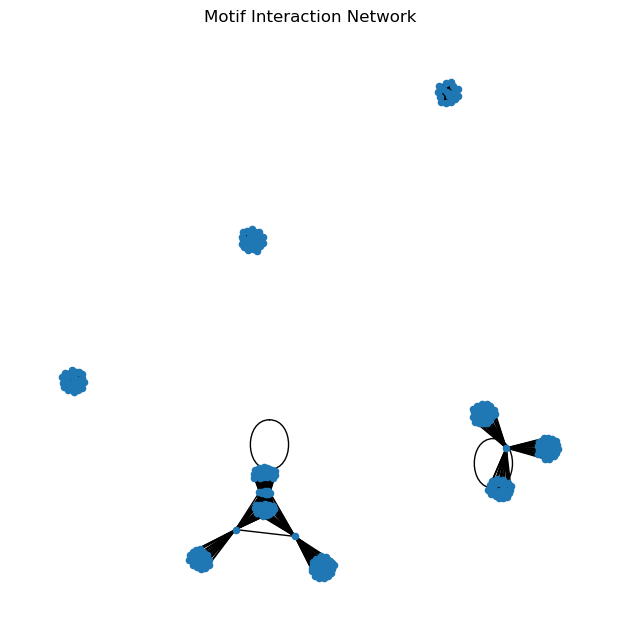

In [ ]:
# ============================================================
# ADVANCED PEPTIDE INTERPRETABILITY PIPELINE (FINAL STABLE)
# ============================================================

import numpy as np
import pandas as pd
import torch
import shap
import esm
from scipy.stats import spearmanr
import networkx as nx
import matplotlib.pyplot as plt
import random

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cpu")

# ============================================================
# LOAD ESM MODEL
# ============================================================
esm_model, esm_alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model = esm_model.to(device)
esm_model.eval()
batch_converter = esm_alphabet.get_batch_converter()

# ============================================================
# MAIN MODEL (assumed loaded)
# ============================================================
model = model.to(device)
model.eval()

# ============================================================
# SAFE FUNCTIONS
# ============================================================
def safe_extract_esm_embeddings(sequences):
    return extract_esm_embeddings(sequences).detach().cpu()

def safe_onehot(sequences):
    return sequence_to_onehot(sequences).float().detach().cpu()

def shap_predict(sequences):
    with torch.no_grad():
        esm_feats = safe_extract_esm_embeddings(sequences)
        onehot = safe_onehot(sequences)
        outputs = model(esm_feats, onehot)
        return torch.softmax(outputs, dim=1).cpu().numpy()

# ============================================================
# SHAP → RESIDUE (ROBUST)
# ============================================================
def map_shap_to_residues(shap_scores, seq_len, k=6):

    shap_scores = np.array(shap_scores, dtype=np.float64)

    if shap_scores.ndim > 1:
        shap_scores = shap_scores.reshape(-1)

    residue_scores = np.zeros(seq_len, dtype=np.float64)
    counts = np.zeros(seq_len, dtype=np.float64)

    for i in range(len(shap_scores)):

        s = float(shap_scores[i])  # force scalar

        for j in range(i, min(i + k, seq_len)):
            residue_scores[j] += s
            counts[j] += 1.0

    counts[counts == 0] = 1.0

    return residue_scores / counts

# ============================================================
# BOOTSTRAP SHAP
# ============================================================
def bootstrap_shap(seq, n_boot=15):

    all_scores = []

    for _ in range(n_boot):

        idx = np.random.choice(len(background_sequences), size=30, replace=True)
        bg = [background_sequences[i] for i in idx]

        explainer = shap.DeepExplainer(
            wrapped_model,
            [safe_extract_esm_embeddings(bg), safe_onehot(bg)]
        )

        shap_vals = explainer.shap_values(
            [safe_extract_esm_embeddings([seq]), safe_onehot([seq])],
            check_additivity=False
        )

        scores = shap_vals[1][0]

        if isinstance(scores, list):
            scores = np.array(scores)

        if scores.ndim == 2:
            scores = scores.sum(axis=1)

        scores = np.nan_to_num(scores).astype(np.float64).reshape(-1)

        all_scores.append(scores)

    return np.array(all_scores)

# ============================================================
# BAYESIAN INTERVALS
# ============================================================
def credible_interval(samples):

    samples = np.array(samples, dtype=np.float64)

    if samples.ndim == 3:
        samples = samples.sum(axis=2)

    mean = np.mean(samples, axis=0)
    mean = np.nan_to_num(mean).reshape(-1)

    return mean

# ============================================================
# ATTENTION (FINAL FIX)
# ============================================================
def get_attention_scores(seq):

    _, _, tokens = batch_converter([("s", seq)])

    with torch.no_grad():
        out = esm_model(tokens, repr_layers=[6], need_head_weights=True)

    attn = out["attentions"]  # [layers, heads, L, L]

    attn = attn.mean(dim=(0,1))  # [L, L]

    # remove CLS/EOS
    attn = attn[1:-1, 1:-1]

    # collapse to 1D
    attn = attn.mean(dim=0)

    attn = attn.detach().cpu().numpy()

    # safety
    if attn.ndim > 1:
        attn = attn.mean(axis=0)

    return np.array(attn, dtype=np.float64).reshape(-1)

# ============================================================
# DISAGREEMENT MAP (FINAL FIX)
# ============================================================
def disagreement_map(shap_res, attn):

    shap_res = np.array(shap_res, dtype=np.float64).reshape(-1)
    attn = np.array(attn, dtype=np.float64)

    if attn.ndim > 1:
        attn = attn.mean(axis=0)

    attn = attn.reshape(-1)

    L = min(len(shap_res), len(attn))

    shap_res = shap_res[:L]
    attn = attn[:L]

    mask = np.isfinite(shap_res) & np.isfinite(attn)

    shap_res = shap_res[mask]
    attn = attn[mask]

    return np.abs(shap_res - attn)

# ============================================================
# COUNTERFACTUAL OPTIMIZATION
# ============================================================
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def optimize_sequence(seq, shap_scores, steps=10):

    seq = list(seq)
    seq_len = len(seq)

    shap_res = map_shap_to_residues(shap_scores, seq_len)

    for _ in range(steps):

        idx = int(np.argmax(np.abs(shap_res)))
        idx = min(idx, seq_len-1)

        aa = random.choice(amino_acids)

        new_seq = seq.copy()
        new_seq[idx] = aa
        new_seq = "".join(new_seq)

        p_old = shap_predict(["".join(seq)])[0][1]
        p_new = shap_predict([new_seq])[0][1]

        if p_new < p_old:
            seq = list(new_seq)

    return "".join(seq)

# ============================================================
# GRAPH NETWORK
# ============================================================
def build_motif_graph(sequences):

    G = nx.Graph()

    for seq in sequences:
        for i in range(len(seq)-2):
            m1 = seq[i:i+3]
            for j in range(i+1, len(seq)-2):
                m2 = seq[j:j+3]
                G.add_edge(m1, m2)

    return G

# ============================================================
# SHAP WRAPPER
# ============================================================
class WrapperModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, esm_feats, onehot):
        return self.model(esm_feats.cpu(), onehot.cpu())

wrapped_model = WrapperModel(model)

# ============================================================
# BACKGROUND
# ============================================================
background_sequences = toxic_sequences[:30]

# ============================================================
# MAIN ANALYSIS
# ============================================================
results = []

for seq in toxic_sequences[:10]:

    shap_samples = bootstrap_shap(seq)

    mean = credible_interval(shap_samples)

    shap_res = map_shap_to_residues(mean, len(seq))

    attn = get_attention_scores(seq)

    # correlation
    L = min(len(shap_res), len(attn))
    corr = spearmanr(shap_res[:L], attn[:L])[0]

    # disagreement
    dis = disagreement_map(shap_res, attn)

    # optimization
    opt_seq = optimize_sequence(seq, mean)

    results.append({
        "sequence": seq,
        "correlation": corr,
        "mean_SHAP": float(np.mean(shap_res)),
        "optimized_sequence": opt_seq
    })

results_df = pd.DataFrame(results)

print("\n📊 FINAL RESULTS")
print(results_df.head())

# ============================================================
# GRAPH VISUALIZATION
# ============================================================
G = build_motif_graph(toxic_sequences[:30])

plt.figure(figsize=(6,6))
nx.draw(G, node_size=20, with_labels=False)
plt.title("Motif Interaction Network")
plt.show()

In [ ]:
# ============================================================
# PHYSICS-INFORMED PEPTIDE PIPELINE
# ✔ ΔG + SASA heuristics
# ✔ Physics-constrained counterfactual optimization
# ============================================================

import numpy as np
import pandas as pd
import torch
import random

# ============================================================
# ASSUMED PRELOADED:
# model
# extract_esm_embeddings()
# sequence_to_onehot()
# toxic_sequences (list of sequences)
# ============================================================

device = torch.device("cpu")
model = model.to(device)
model.eval()

# ============================================================
# SAFE PREDICTION FUNCTION
# ============================================================
def safe_extract_esm_embeddings(sequences):
    return extract_esm_embeddings(sequences).detach().cpu()

def safe_onehot(sequences):
    return sequence_to_onehot(sequences).float().detach().cpu()

def predict_proba(sequences):
    with torch.no_grad():
        esm_feats = safe_extract_esm_embeddings(sequences)
        onehot = safe_onehot(sequences)
        outputs = model(esm_feats, onehot)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
    return probs

# ============================================================
# PHYSICS-INFORMED FEATURES
# ============================================================

hydrophobicity_scale = {
    'A':1.8,'C':2.5,'D':-3.5,'E':-3.5,'F':2.8,'G':-0.4,
    'H':-3.2,'I':4.5,'K':-3.9,'L':3.8,'M':1.9,'N':-3.5,
    'P':-1.6,'Q':-3.5,'R':-4.5,'S':-0.8,'T':-0.7,
    'V':4.2,'W':-0.9,'Y':-1.3
}

def estimate_ddG(seq):
    """
    Approximate ΔG:
    More hydrophobic → more stable → lower ΔG
    """
    hydro = np.array([hydrophobicity_scale.get(a, 0.0) for a in seq], dtype=np.float64)
    return -np.mean(hydro)

def estimate_sasa(seq):
    """
    Approximate SASA:
    polar/charged residues → higher exposure
    """
    polar = set("DEKRHNQSTY")
    return sum(aa in polar for aa in seq) / len(seq)

def physics_filter(seq, ddG_thresh=1.0, sasa_thresh=0.6):
    """
    Accept only physically plausible peptides
    """
    ddG = estimate_ddG(seq)
    sasa = estimate_sasa(seq)
    return (ddG < ddG_thresh) and (sasa < sasa_thresh)

# ============================================================
# SHAP → RESIDUE (GENERIC IMPORTANCE MAPPING)
# ============================================================
def map_importance_to_residues(scores, seq_len, k=6):

    scores = np.array(scores, dtype=np.float64).reshape(-1)

    residue_scores = np.zeros(seq_len, dtype=np.float64)
    counts = np.zeros(seq_len, dtype=np.float64)

    for i in range(len(scores)):
        s = float(scores[i])
        for j in range(i, min(i + k, seq_len)):
            residue_scores[j] += s
            counts[j] += 1.0

    counts[counts == 0] = 1.0
    return residue_scores / counts

# ============================================================
# PHYSICS-CONSTRAINED COUNTERFACTUAL OPTIMIZATION
# ============================================================

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

def optimize_sequence(seq, importance_scores, steps=20):

    seq_list = list(seq)
    seq_len = len(seq_list)

    # map importance to residues
    importance_res = map_importance_to_residues(importance_scores, seq_len)

    for _ in range(steps):

        # mutate most important residue
        idx = int(np.argmax(np.abs(importance_res)))
        idx = min(idx, seq_len - 1)

        new_seq_list = seq_list.copy()
        new_aa = random.choice(amino_acids)
        new_seq_list[idx] = new_aa

        new_seq = "".join(new_seq_list)

        # 🔴 PHYSICS FILTER
        if not physics_filter(new_seq):
            continue

        # evaluate model
        p_old = predict_proba(["".join(seq_list)])[0][1]
        p_new = predict_proba([new_seq])[0][1]

        # accept improvement
        if p_new < p_old:
            seq_list = list(new_seq)

    return "".join(seq_list)

# ============================================================
# OPTIONAL: SIMPLE IMPORTANCE (RANDOM OR PRECOMPUTED SHAP)
# ============================================================
def dummy_importance(seq):
    """
    Replace with SHAP or other attribution method
    """
    return np.random.randn(len(seq))

# ============================================================
# APPLY PIPELINE
# ============================================================

results = []

for seq in toxic_sequences[:10]:

    # importance (replace with SHAP if available)
    importance_scores = dummy_importance(seq)

    optimized_seq = optimize_sequence(seq, importance_scores)

    results.append({
        "sequence": seq,
        "optimized_sequence": optimized_seq,
        "ddG_original": estimate_ddG(seq),
        "SASA_original": estimate_sasa(seq),
        "ddG_optimized": estimate_ddG(optimized_seq),
        "SASA_optimized": estimate_sasa(optimized_seq),
        "original_prob": predict_proba([seq])[0][1],
        "optimized_prob": predict_proba([optimized_seq])[0][1],
        "passes_physics_original": physics_filter(seq),
        "passes_physics_optimized": physics_filter(optimized_seq)
    })

# ============================================================
# RESULTS
# ============================================================

results_df = pd.DataFrame(results)

print("\n📊 Physics-Constrained Optimization Results")
print(results_df.head())


📊 Physics-Constrained Optimization Results
                          sequence               optimized_sequence  \
0        VQYPVEHPNKFLKFGMTPSKGVLFY        VQYPVEHPNKFEKFGMTPSKGVLFY   
1       AKAWGIPPHVIPQIVPVRIRPLCGNV       QKAWGIPPHVIPQIVPVRIRPLCGNV   
2  GFWDSVKEGLKNAAVTILNKIKCKISECPPA  GFWDSVKEGLKNAAVTILNKIKCKISEVPPA   
3       FIPGLRRLFATVVPTVVCAINKLPPG       FVPGLRRLFATVVPTVVCAINKLPPG   
4       SIITMTKEAKLPQLWKQIACRLYNTC       KIITMTKEAKLPQLWKQIACRLYNTC   

   ddG_original  SASA_original  ddG_optimized  SASA_optimized  original_prob  \
0      0.184000       0.440000       0.476000        0.480000       0.951042   
1     -0.457692       0.230769      -0.253846        0.269231       0.951052   
2      0.048387       0.419355      -0.006452        0.419355       0.950686   
3     -0.919231       0.230769      -0.907692        0.230769       0.951022   
4      0.057692       0.500000       0.176923        0.500000       0.951075   

   optimized_prob  passes_physics_original  pass